# Lending Club Loan — Full Preprocessing Pipeline
Data Mining Project | Preprocessing Phase

---
## Dua Dataset yang Digunakan

| Dataset | File | Baris | Kolom | Deskripsi |
|---|---|---|---|---|
| `df_acc` | accepted_2007_to_2018Q4.csv | ~2.26 juta | 151 | Pinjaman yang diterima |
| `df_rej` | rejected_2007_to_2018Q4.csv | ~27.6 juta | 9 | Pinjaman yang ditolak |

Strategi pipeline:
df_acc diproses secara penuh (EDA, Cleaning, Transform, Feature Selection) karena memiliki
banyak fitur dan target label loan_status.
df_rej diproses secara terpisah dengan pipeline lebih sederhana, lalu digabung untuk analisis komparatif.
Keduanya digabung menjadi df_combined sebagai clean final dataset.

---
# Setup — Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Library berhasil diimport')

Library berhasil diimport


---
# Load Data — Membaca Kedua CSV

In [2]:
df_acc = pd.read_csv(
    'accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv',
    low_memory=False
)
print(f'df_acc: {df_acc.shape[0]:,} baris x {df_acc.shape[1]} kolom')

df_rej = pd.read_csv(
    'rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv',
    low_memory=False
)
print(f'df_rej: {df_rej.shape[0]:,} baris x {df_rej.shape[1]} kolom')

df_acc: 2,260,701 baris x 151 kolom
df_rej: 27,648,741 baris x 9 kolom


---
# Fase 1 — Exploratory Data Analysis (EDA)

Tujuan: Kenali data sebelum menyentuhnya. Pahami struktur, distribusi, dan masalah kualitas data.

## 1.1 — Struktur Data

In [3]:
print('RINGKASAN df_acc (ACCEPTED LOANS)')
print(f'Jumlah baris  : {df_acc.shape[0]:,}')
print(f'Jumlah kolom  : {df_acc.shape[1]}')
print(f'Memory usage  : {df_acc.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print()
print('Tipe data:')
print(df_acc.dtypes.value_counts())
df_acc.head()

RINGKASAN df_acc (ACCEPTED LOANS)
Jumlah baris  : 2,260,701
Jumlah kolom  : 151
Memory usage  : 6.28 GB

Tipe data:
float64    113
object      38
Name: count, dtype: int64


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.00,35000.00,35000.00,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.00,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.06,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.00,10400.00,10400.00,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.00,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.37,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print('RINGKASAN df_rej (REJECTED LOANS)')
print(f'Jumlah baris  : {df_rej.shape[0]:,}')
print(f'Jumlah kolom  : {df_rej.shape[1]}')
print(f'Memory usage  : {df_rej.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print()
print('Tipe data:')
print(df_rej.dtypes.value_counts())
df_rej.head()

RINGKASAN df_rej (REJECTED LOANS)
Jumlah baris  : 27,648,741
Jumlah kolom  : 9
Memory usage  : 10.00 GB

Tipe data:
object     6
float64    3
Name: count, dtype: int64


,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.00,2007-05-26,Wedding Covered but No Honeymoon,693.00,10%,481xx,NM,4 years,0.00
1,1000.00,2007-05-26,Consolidating Debt,703.00,10%,010xx,MA,< 1 year,0.00
2,11000.00,2007-05-27,Want to consolidate my debt,715.00,10%,212xx,MD,1 year,0.00
3,6000.00,2007-05-27,waksman,698.00,38.64%,017xx,MA,< 1 year,0.00
4,1500.00,2007-05-27,mdrigo,509.00,9.43%,209xx,MD,< 1 year,0.00


## 1.2 — Analisis Missing Values

In [5]:
def missing_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': pct,
        'Dtype': df.dtypes
    })
    report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'Missing Value Report — {name}')
    print(f'Total kolom dengan missing : {len(report)} dari {df.shape[1]}')
    print(f'Kolom dengan >50% missing  : {(report["Missing %"] > 50).sum()}')
    print(f'Kolom dengan >90% missing  : {(report["Missing %"] > 90).sum()}')
    return report

In [6]:
missing_acc = missing_report(df_acc, 'df_acc')
print('\nTop 20 kolom dengan missing terbanyak:')
missing_acc.head(20)

Missing Value Report — df_acc
Total kolom dengan missing : 150 dari 151
Kolom dengan >50% missing  : 44
Kolom dengan >90% missing  : 38

Top 20 kolom dengan missing terbanyak:


,Missing Count,Missing %,Dtype
member_id,2260701,100.00,float64
orig_projected_additional_accrued_interest,2252050,99.62,float64
hardship_payoff_balance_amount,2249784,99.52,float64
hardship_last_payment_amount,2249784,99.52,float64
payment_plan_start_date,2249784,99.52,object
hardship_type,2249784,99.52,object
hardship_status,2249784,99.52,object
hardship_start_date,2249784,99.52,object
deferral_term,2249784,99.52,float64
hardship_amount,2249784,99.52,float64


In [7]:
missing_rej = missing_report(df_rej, 'df_rej')
print('\nSemua kolom missing di df_rej:')
missing_rej

Missing Value Report — df_rej
Total kolom dengan missing : 6 dari 9
Kolom dengan >50% missing  : 1
Kolom dengan >90% missing  : 0

Semua kolom missing di df_rej:


,Missing Count,Missing %,Dtype
Risk_Score,18497630,66.90,float64
Employment Length,951355,3.44,object
Loan Title,1305,0.00,object
Zip Code,293,0.00,object
State,22,0.00,object
Policy Code,918,0.00,float64


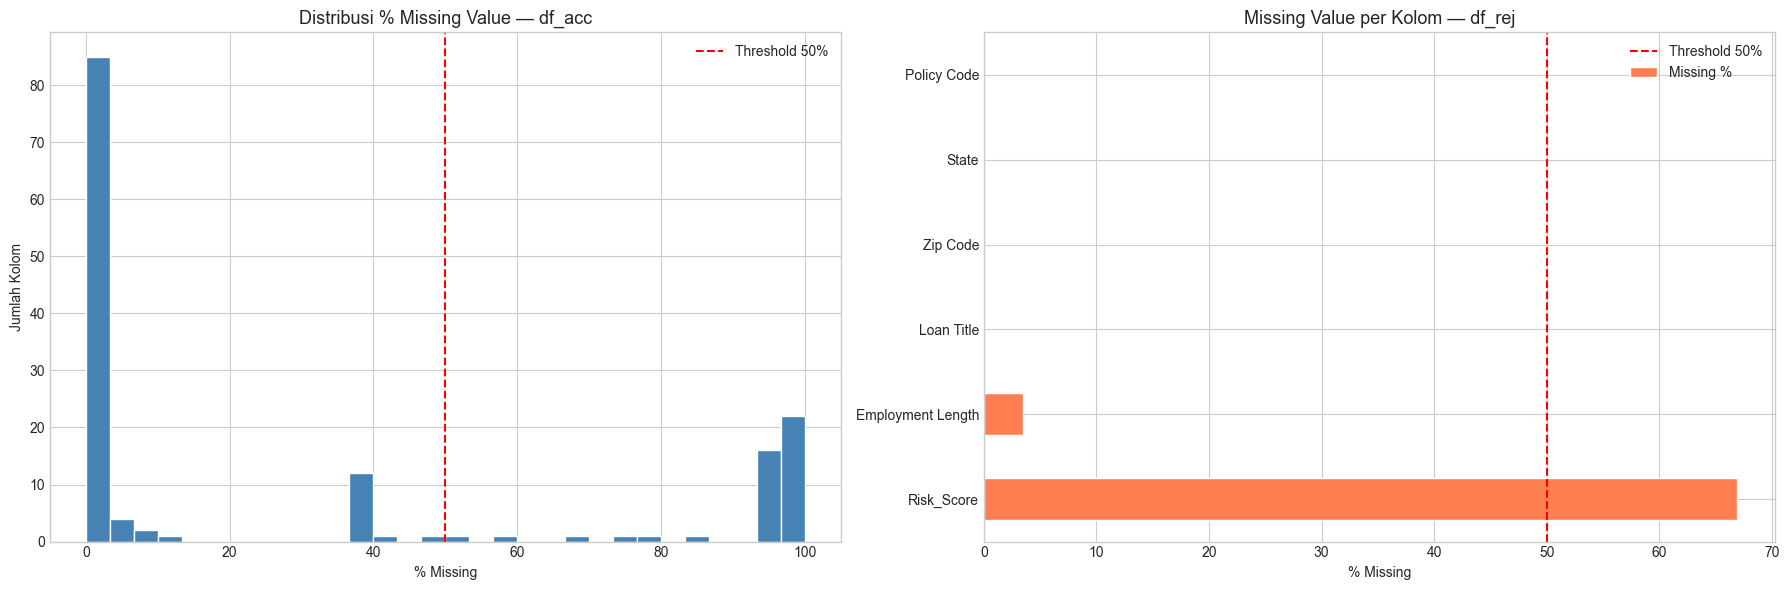

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

missing_acc['Missing %'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi % Missing Value — df_acc', fontsize=13)
axes[0].set_xlabel('% Missing')
axes[0].set_ylabel('Jumlah Kolom')
axes[0].axvline(x=50, color='red', linestyle='--', label='Threshold 50%')
axes[0].legend()

if len(missing_rej) > 0:
    missing_rej['Missing %'].plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
    axes[1].set_title('Missing Value per Kolom — df_rej', fontsize=13)
    axes[1].set_xlabel('% Missing')
    axes[1].axvline(x=50, color='red', linestyle='--', label='Threshold 50%')
    axes[1].legend()

plt.tight_layout()
plt.savefig('missing_value_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Missing Value Analysis:

Histogram df_acc menunjukkan distribusi right-skewed — mayoritas kolom memiliki missing
rendah di bawah 10%, namun ada ekor panjang ke kanan berupa kolom dengan missing sangat
tinggi di atas 80%. Kolom-kolom tersebut (hardship, settlement, dll) akan di-drop karena
tidak bisa diimputasi secara andal.

Bar chart df_rej menunjukkan Risk_Score memiliki missing di atas 50% dan menjadi kandidat
drop utama. Dataset df_rej secara umum lebih bersih karena jumlah kolomnya jauh lebih sedikit.

Threshold 50% dipilih karena kolom dengan mayoritas nilai kosong akan mengintroduksi lebih
banyak noise daripada sinyal jika diimputasi. Kolom di bawah threshold diimputasi menggunakan
median untuk numerik dan modus untuk kategorik karena keduanya robust terhadap distribusi skewed.

## 1.3 — Analisis Distribusi Kolom Numerik

In [9]:
print('Statistik Deskriptif df_acc (numerik):')
df_acc.describe().T

Statistik Deskriptif df_acc (numerik):


,count,mean,std,min,25%,50%,75%,max
member_id,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.00,15046.93,9190.25,500.00,8000.00,12900.00,20000.00,40000.00
funded_amnt,2260668.00,15041.66,9188.41,500.00,8000.00,12875.00,20000.00,40000.00
funded_amnt_inv,2260668.00,15023.44,9192.33,0.00,8000.00,12800.00,20000.00,40000.00
int_rate,2260668.00,13.09,4.83,5.31,9.49,12.62,15.99,30.99
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10917.00,11636.88,7625.99,55.73,5627.00,10028.39,16151.89,40306.41
hardship_last_payment_amount,10917.00,193.99,198.63,0.01,44.44,133.16,284.19,1407.86
settlement_amount,34246.00,5010.66,3693.12,44.21,2208.00,4146.11,6850.17,33601.00
settlement_percentage,34246.00,47.78,7.31,0.20,45.00,45.00,50.00,521.35


Sebagian besar fitur numerik memiliki distribusi yang cukup baik. Namun ditemukan beberapa
kolom dengan missing tinggi seperti member_id dan hardship-related features yang kemungkinan
akan dihapus. Terdapat indikasi outlier pada beberapa variabel seperti settlement_percentage
dengan max 521.35% yang melebihi batas wajar. Fitur seperti loan_amnt menunjukkan mean lebih
besar dari median, mengindikasikan distribusi right-skewed.

Pemilihan fitur numerik dilakukan berdasarkan relevansi terhadap risiko kredit dan representasi
aspek finansial peminjam. Fitur seperti int_rate, dti, dan fico_range_low dipilih karena secara
langsung merepresentasikan tingkat risiko, sementara annual_inc dan installment menggambarkan
kemampuan pembayaran. Fitur yang redundan dieliminasi untuk menghindari multikolinearitas.

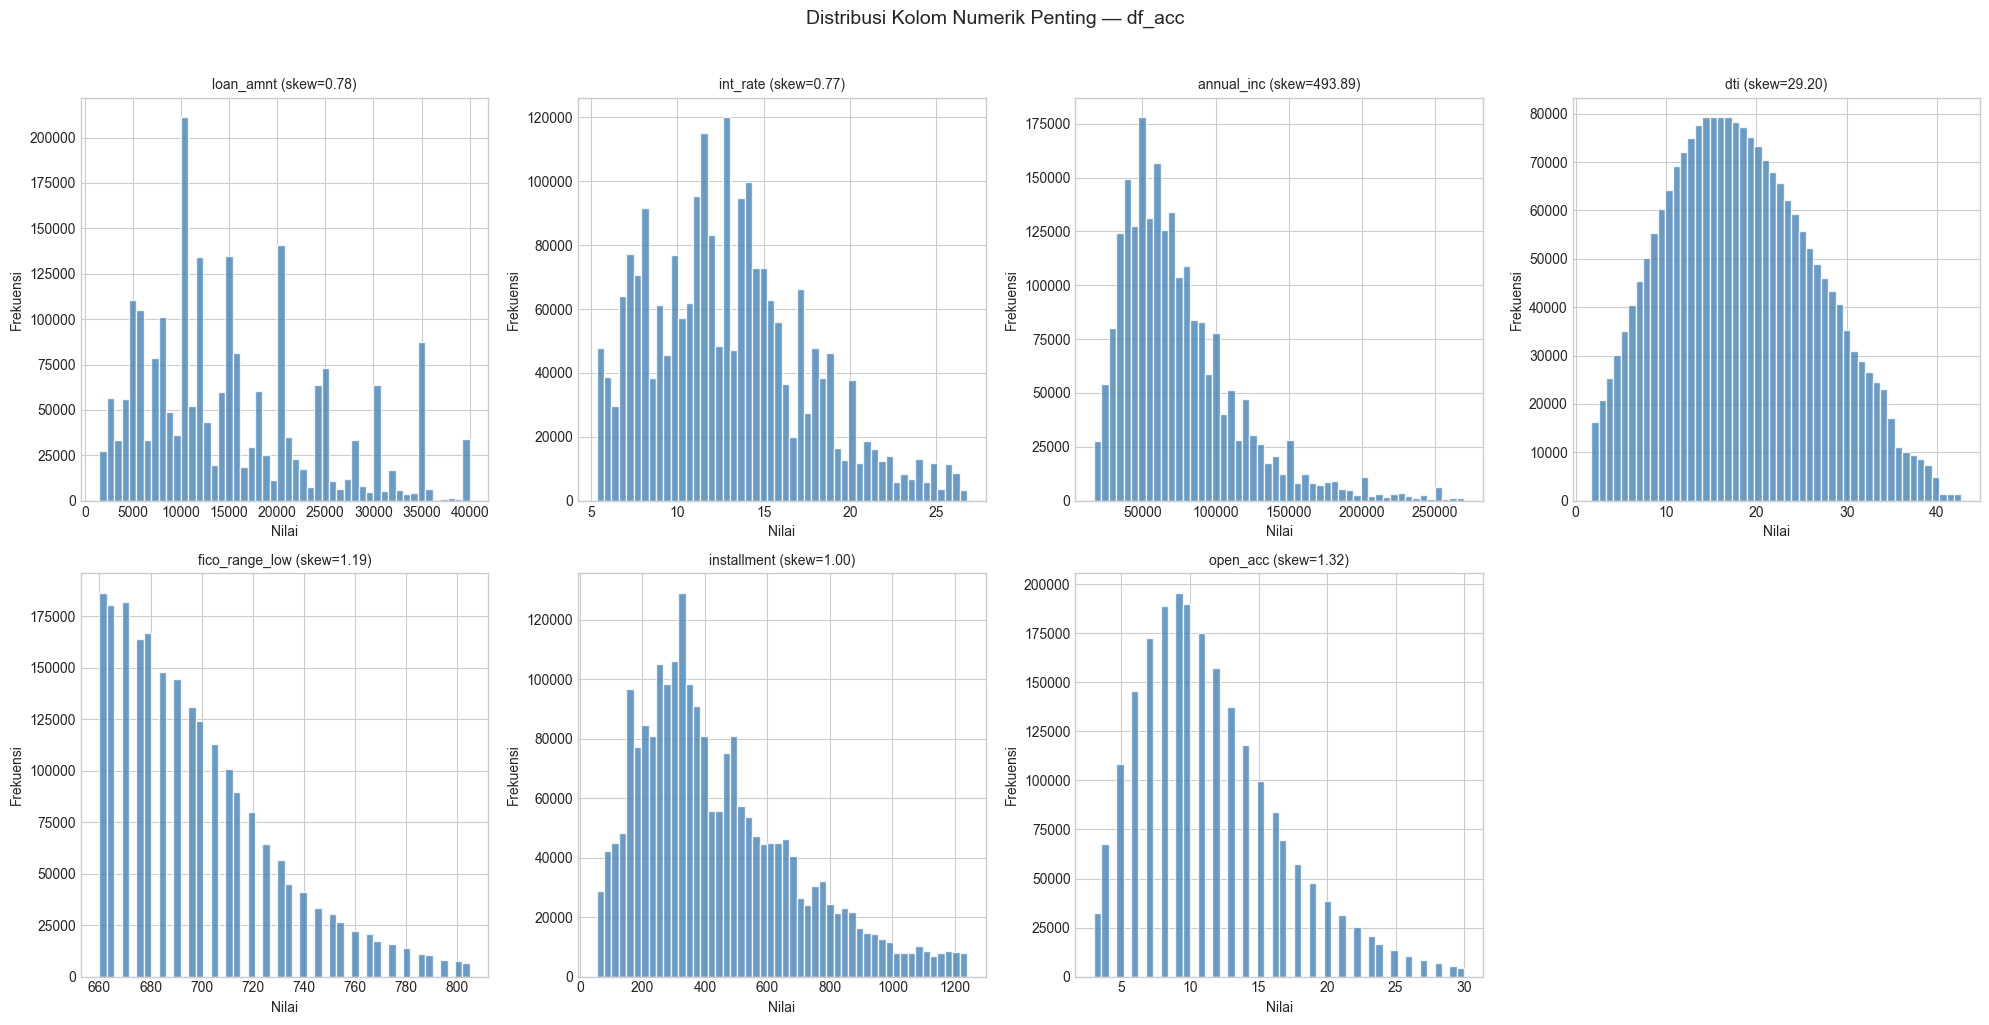

Skew > 1  : positively skewed
Skew < -1 : negatively skewed
Skew ~= 0 : mendekati normal


In [10]:
key_numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                    'fico_range_low', 'installment', 'open_acc']
key_numeric_cols = [c for c in key_numeric_cols if c in df_acc.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric_cols):
    data = df_acc[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    data_clipped = data[(data >= p1) & (data <= p99)]
    axes[i].hist(data_clipped, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} (skew={data.skew():.2f})', fontsize=10)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for j in range(len(key_numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Kolom Numerik Penting — df_acc', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('distribusi_numerik.png', dpi=120, bbox_inches='tight')
plt.show()

print('Skew > 1  : positively skewed')
print('Skew < -1 : negatively skewed')
print('Skew ~= 0 : mendekati normal')

Distribusi fitur numerik menunjukkan mayoritas variabel memiliki positive skewness.
annual_inc cenderung berdistribusi power law karena data pendapatan tidak memiliki batas
atas alami. dti menunjukkan right-skewed moderat yang bisa ditangani dengan IQR capping.

Penanganan outlier untuk kedua fitur ini berbeda:
- annual_inc tidak bisa menggunakan IQR capping. IQR capping memotong ekor kanan terlalu
  agresif sehingga ketika log transform diterapkan setelahnya, tidak ada ekor yang tersisa
  untuk dikompresi dan distribusi justru berbalik menjadi left-skewed (overcorrect).
  Oleh karena itu annual_inc ditangani dengan percentile clipping P1-P99 diikuti log1p.
- dti cukup ditangani dengan IQR capping karena setelah capping skewnessnya sudah
  mendekati simetris dan tidak membutuhkan log transform tambahan.

Distribusi Target Variable (loan_status):
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Persentase:
loan_status
Fully Paid                                             47.63%
Current                                                38.85%
Charged Off                                            11.88%
Late (31-120 days)                                      0.95%
In Grace Period                                         0.37%
Late (16-30 days) 

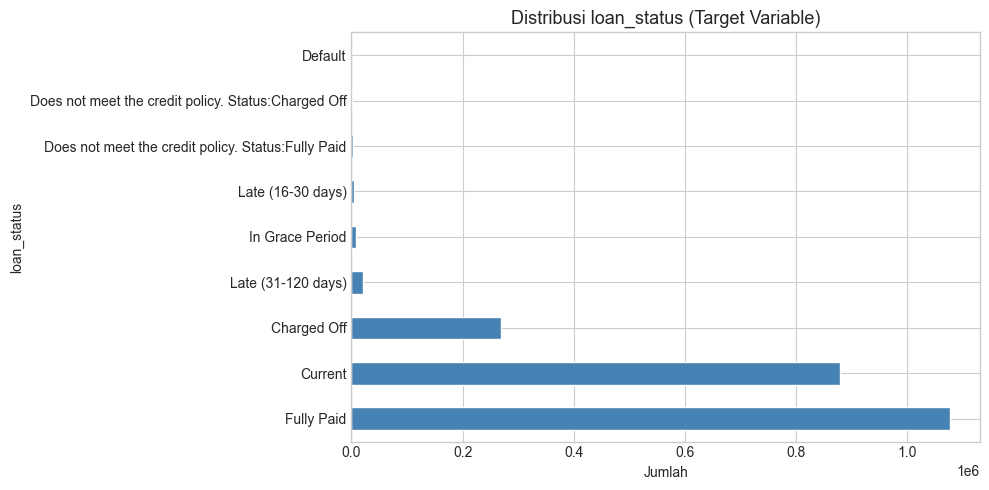

In [11]:
print('Distribusi Target Variable (loan_status):')
print(df_acc['loan_status'].value_counts())
print()
print('Persentase:')
print(df_acc['loan_status'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

fig, ax = plt.subplots(figsize=(10, 5))
df_acc['loan_status'].value_counts().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribusi loan_status (Target Variable)', fontsize=13)
ax.set_xlabel('Jumlah')
plt.tight_layout()
plt.savefig('loan_status_dist.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Distribusi Target Variable:

Distribusi awal menunjukkan Fully Paid sekitar 47.63% merupakan status paling dominan,
sementara Current sekitar 38.85% juga signifikan namun belum memiliki outcome final.
Charged Off sekitar 11.88% merepresentasikan pinjaman gagal bayar atau default.

Status Current, Late, dan In Grace Period dikeluarkan dari analisis karena belum mencerminkan
hasil akhir pinjaman dan dapat menyebabkan label noise dalam proses modeling.

## 1.4 — Analisis Outlier

In [12]:
def detect_outliers_iqr(df, cols):
    results = []
    for col in cols:
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data < lower) | (data > upper)).sum()
        results.append({
            'Kolom': col,
            'Lower Bound': lower,
            'Upper Bound': upper,
            'Jumlah Outlier': n_outliers,
            '% Outlier': round(n_outliers / len(data) * 100, 2)
        })
    return pd.DataFrame(results).sort_values('% Outlier', ascending=False)

In [13]:
numeric_cols_acc = df_acc.select_dtypes(include='number').columns.tolist()
valid_num_cols = [c for c in numeric_cols_acc if df_acc[c].dropna().shape[0] > 1000][:20]

outlier_report = detect_outliers_iqr(df_acc, valid_num_cols)
print('Laporan Outlier (IQR Method) — df_acc:')
outlier_report

Laporan Outlier (IQR Method) — df_acc:


,Kolom,Lower Bound,Upper Bound,Jumlah Outlier,% Outlier
7,delinq_2yrs,0.00,0.00,421531,18.65
14,pub_rec,0.00,0.00,357881,15.83
18,out_prncp,-9224.91,15374.85,212242,9.39
19,out_prncp_inv,-9219.47,15365.78,212305,9.39
15,revol_bal,-15494.00,41690.00,137095,6.06
5,annual_inc,-24500.00,163500.00,110041,4.87
10,inq_last_6mths,-1.50,2.50,94314,4.17
13,open_acc,-1.00,23.00,84754,3.75
8,fico_range_low,615.00,775.00,74846,3.31
9,fico_range_high,619.00,779.00,74846,3.31


Catatan untuk kolom zero-inflated seperti delinq_2yrs dan pub_rec:
IQR = 0 bukan berarti semua nilai di atas 0 adalah outlier. Kolom ini memiliki distribusi
zero-inflated di mana mayoritas bernilai 0, sehingga metode IQR tidak tepat diterapkan
dan kolom ini dikecualikan dari capping.

Terdapat juga lower bound negatif pada kolom yang secara domain tidak mungkin negatif
seperti loan_amnt dan revol_bal. Batas bawah IQR secara teoritis bisa negatif, namun
nilai negatif di kolom ini tetap di-cap ke 0 berdasarkan domain knowledge.

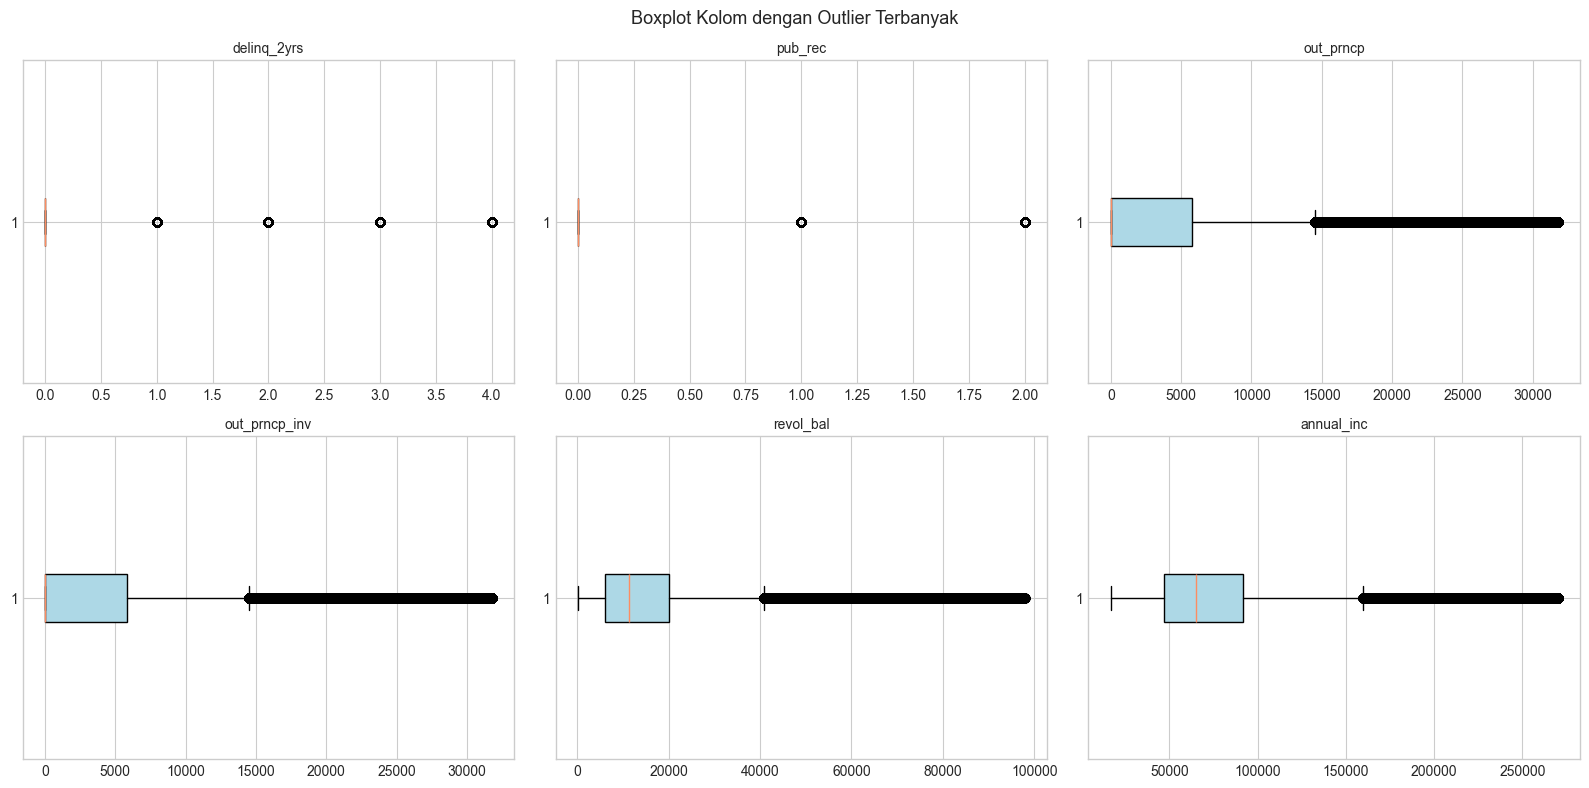

In [14]:
top_outlier_cols = outlier_report.head(6)['Kolom'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    data = df_acc[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    axes[i].boxplot(
        data[(data >= p1) & (data <= p99)],
        vert=False, patch_artist=True,
        boxprops=dict(facecolor='lightblue')
    )
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Boxplot Kolom dengan Outlier Terbanyak', fontsize=13)
plt.tight_layout()
plt.savefig('outlier_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Outlier Analysis:

Boxplot menunjukkan bahwa outlier ekstrem umumnya berada di sisi kanan (upper), konsisten
dengan distribusi right-skewed yang sudah diamati sebelumnya. annual_inc dan revol_bal
memiliki outlier paling ekstrem di antara seluruh fitur yang dianalisis.

Untuk sebagian besar fitur, outlier ditangani dengan IQR capping (winsorization): nilai
di luar batas IQR di-clip tanpa menghapus baris, sehingga tidak ada data yang hilang.

annual_inc adalah pengecualian. IQR capping tidak bisa digunakan untuk annual_inc karena
IQR upper bound memotong sekitar 5% data di sisi kanan, jauh terlalu agresif untuk
distribusi power law. Jika log transform kemudian diterapkan pada annual_inc yang sudah
di-cap, ekor kanannya sudah terlalu pendek sehingga log overcorrect dan menghasilkan
distribusi left-skewed. Oleh karena itu annual_inc akan ditangani dengan percentile
clipping P1-P99 yang hanya membuang 1% nilai paling ekstrem, diikuti log1p.

## 1.5 — Analisis Kolom Kategorik

In [15]:
cat_cols = df_acc.select_dtypes(include='object').columns.tolist()
print(f'Jumlah kolom kategorik: {len(cat_cols)}')
print()

cat_summary = pd.DataFrame({
    'Kolom': cat_cols,
    'Unique Values': [df_acc[c].nunique() for c in cat_cols],
    'Contoh Nilai': [str(df_acc[c].dropna().unique()[:3].tolist()) for c in cat_cols],
    'Missing %': [round(df_acc[c].isnull().mean() * 100, 1) for c in cat_cols]
})
cat_summary.sort_values('Unique Values').head(20)

Jumlah kolom kategorik: 38



,Kolom,Unique Values,Contoh Nilai,Missing %
26,hardship_type,1,['INTEREST ONLY-3 MONTHS DEFERRAL'],99.50
1,term,2,"[' 36 months', ' 60 months']",0.00
18,initial_list_status,2,"['w', 'f']",0.00
10,pymnt_plan,2,"['n', 'y']",0.00
22,application_type,2,"['Individual', 'Joint App']",0.00
25,hardship_flag,2,"['N', 'Y']",0.00
34,debt_settlement_flag,2,"['N', 'Y']",0.00
33,disbursement_method,2,"['Cash', 'DirectPay']",0.00
28,hardship_status,3,"['BROKEN', 'COMPLETED', 'ACTIVE']",99.50
36,settlement_status,3,"['COMPLETE', 'BROKEN', 'ACTIVE']",98.50


Pemilihan fitur kategorik dilakukan berdasarkan relevansi domain terhadap risiko kredit,
kelengkapan data, jumlah kategori yang terkelola, serta kemampuan fitur dalam memberikan
informasi terhadap target. Fitur seperti grade, term, dan purpose dipilih karena memiliki
hubungan langsung dengan profil risiko peminjam, sementara fitur dengan missing tinggi
atau variansi rendah tidak digunakan.

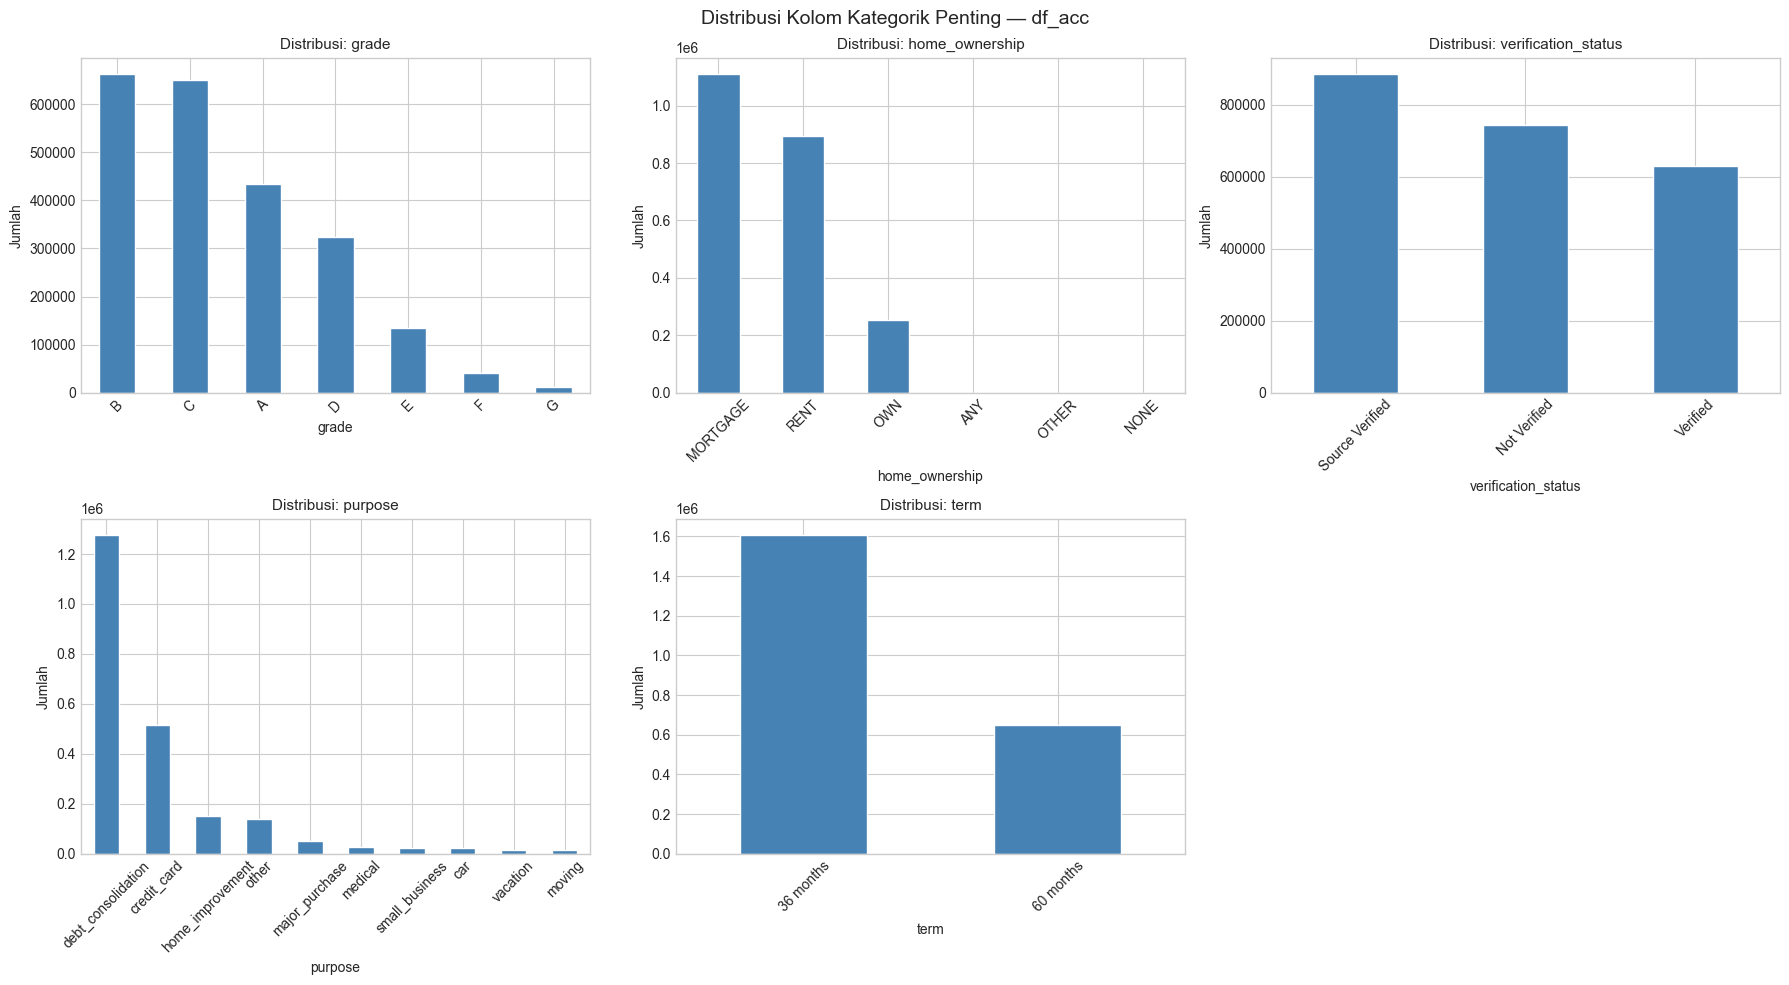

In [16]:
important_cat = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term']
important_cat = [c for c in important_cat if c in df_acc.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(important_cat):
    df_acc[col].value_counts().head(10).plot(
        kind='bar', ax=axes[i], color='steelblue', edgecolor='white'
    )
    axes[i].set_title(f'Distribusi: {col}', fontsize=11)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(important_cat), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Kolom Kategorik Penting — df_acc', fontsize=14)
plt.tight_layout()
plt.savefig('distribusi_kategorik.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Distribusi Fitur Kategorik:

Distribusi grade menunjukkan konsentrasi pada kategori menengah B dan C dengan penurunan
frekuensi pada grade berisiko tinggi D hingga G. Mayoritas peminjam berada pada profil
risiko menengah.

Distribusi home_ownership didominasi RENT dan MORTGAGE, menunjukkan sebagian besar peminjam
masih memiliki kewajiban perumahan yang berpotensi meningkatkan beban finansial.

Distribusi purpose menunjukkan debt_consolidation mendominasi, yang umum di platform P2P
lending karena banyak peminjam menggunakan platform untuk melunasi utang lama.

Distribusi verification_status dengan proporsi Not Verified yang tinggi menjadi fitur
prediktif penting karena peminjam yang tidak diverifikasi memiliki risiko yang lebih
sulit dinilai.

## 1.6 — EDA Khusus df_rej (Rejected Loans)

In [17]:
print('Statistik Deskriptif df_rej:')
print(df_rej.describe())
print()
print('Kolom kategorik df_rej:')
for col in df_rej.select_dtypes(include='object').columns:
    print(f'  {col}: {df_rej[col].nunique()} nilai unik — contoh: {df_rej[col].dropna().unique()[:4]}')

Statistik Deskriptif df_rej:
       Amount Requested  Risk_Score  Policy Code
count       27648741.00  9151111.00  27647823.00
mean           13133.24      628.17         0.01
std            15009.64       89.94         0.11
min                0.00        0.00         0.00
25%             4800.00      591.00         0.00
50%            10000.00      637.00         0.00
75%            20000.00      675.00         0.00
max          1400000.00      990.00         2.00

Kolom kategorik df_rej:
  Application Date: 4238 nilai unik — contoh: ['2007-05-26' '2007-05-27' '2007-05-28' '2007-05-29']
  Loan Title: 73927 nilai unik — contoh: ['Wedding Covered but No Honeymoon' 'Consolidating Debt'
 'Want to consolidate my debt' 'waksman']
  Debt-To-Income Ratio: 126145 nilai unik — contoh: ['10%' '38.64%' '9.43%' '0%']
  Zip Code: 1001 nilai unik — contoh: ['481xx' '010xx' '212xx' '017xx']
  State: 51 nilai unik — contoh: ['NM' 'MA' 'MD' 'NY']
  Employment Length: 11 nilai unik — contoh: ['4 years' 

Dataset rejected menunjukkan karakteristik distribusi yang tidak seimbang dengan outlier
ekstrem pada Amount Requested, serta beberapa fitur dengan kualitas data rendah seperti
Risk Score yang memiliki banyak missing value. Terdapat juga fitur yang perlu transformasi
tipe seperti Debt-To-Income Ratio yang tersimpan dalam format string. Fitur State dan
Employment Length tetap relevan karena mengandung informasi yang berkontribusi terhadap
profil risiko.

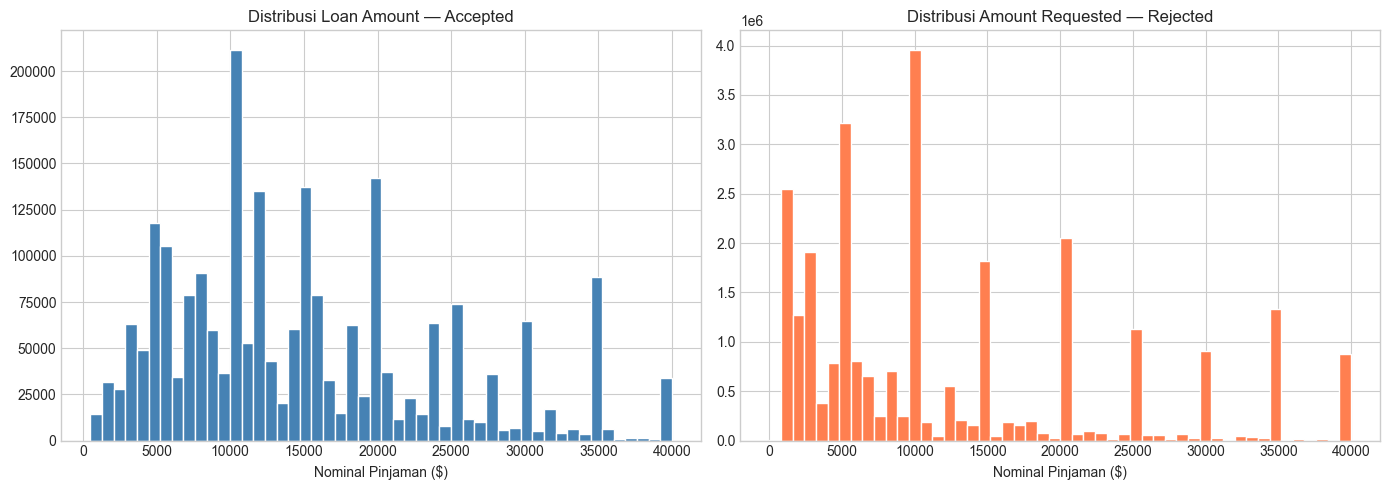

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99 = df_acc['loan_amnt'].quantile(0.99)
df_acc['loan_amnt'][df_acc['loan_amnt'] <= p99].hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribusi Loan Amount — Accepted', fontsize=12)
axes[0].set_xlabel('Nominal Pinjaman ($)')

p99r = df_rej['Amount Requested'].quantile(0.99)
df_rej['Amount Requested'][df_rej['Amount Requested'] <= p99r].hist(
    bins=50, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Distribusi Amount Requested — Rejected', fontsize=12)
axes[1].set_xlabel('Nominal Pinjaman ($)')

plt.tight_layout()
plt.savefig('acc_vs_rej_amount.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Distribusi Amount Accepted vs Rejected:

Distribusi loan amount pada accepted dan amount requested pada rejected sama-sama menunjukkan
pola right-skewed dengan konsentrasi pada nilai pinjaman rendah hingga menengah. Namun
terdapat perbedaan distribusi yang mengindikasikan proses seleksi dalam kebijakan kredit.

Rejected loans bukan sampel acak melainkan hasil filtering berdasarkan kriteria tertentu,
sehingga tidak merepresentasikan populasi secara keseluruhan. Penggabungan kedua dataset
untuk analisis komparatif harus mempertimbangkan selection bias ini.

---
# Fase 2 — Data Cleaning

Prinsip: Setiap keputusan cleaning harus ada justifikasinya.

## 2.1 — Cleaning df_acc: Drop Kolom Bermasalah

In [19]:
df_acc_clean = df_acc.copy()
print(f'Shape awal: {df_acc_clean.shape}')

Shape awal: (2260701, 151)


Langkah 2: Drop kolom dengan lebih dari 50% missing value.
Kolom yang lebih dari setengah nilainya kosong tidak bisa diimputasi secara andal
tanpa mengintroduksi bias yang signifikan.

In [20]:
missing_pct = df_acc_clean.isnull().mean() * 100
cols_to_drop_missing = missing_pct[missing_pct > 50].index.tolist()

print(f'Kolom yang akan di-drop (>50% missing): {len(cols_to_drop_missing)}')
for col in cols_to_drop_missing:
    print(f'  {col}: {missing_pct[col]:.1f}% missing')

df_acc_clean.drop(columns=cols_to_drop_missing, inplace=True)
print(f'Shape setelah drop: {df_acc_clean.shape}')

Kolom yang akan di-drop (>50% missing): 44
  member_id: 100.0% missing
  desc: 94.4% missing
  mths_since_last_delinq: 51.2% missing
  mths_since_last_record: 84.1% missing
  next_pymnt_d: 59.5% missing
  mths_since_last_major_derog: 74.3% missing
  annual_inc_joint: 94.7% missing
  dti_joint: 94.7% missing
  verification_status_joint: 94.9% missing
  mths_since_recent_bc_dlq: 77.0% missing
  mths_since_recent_revol_delinq: 67.3% missing
  revol_bal_joint: 95.2% missing
  sec_app_fico_range_low: 95.2% missing
  sec_app_fico_range_high: 95.2% missing
  sec_app_earliest_cr_line: 95.2% missing
  sec_app_inq_last_6mths: 95.2% missing
  sec_app_mort_acc: 95.2% missing
  sec_app_open_acc: 95.2% missing
  sec_app_revol_util: 95.3% missing
  sec_app_open_act_il: 95.2% missing
  sec_app_num_rev_accts: 95.2% missing
  sec_app_chargeoff_within_12_mths: 95.2% missing
  sec_app_collections_12_mths_ex_med: 95.2% missing
  sec_app_mths_since_last_major_derog: 98.4% missing
  hardship_type: 99.5% miss

Langkah 3: Drop kolom ID dan non-informatif.
id adalah identifier unik pinjaman yang tidak mengandung informasi prediktif.
url adalah link halaman pinjaman yang tidak relevan untuk analisis.
emp_title, zip_code, dan title memiliki cardinality sangat tinggi sehingga tidak stabil sebagai fitur.
Catatan: member_id dan desc sudah di-drop di Langkah 2 karena memiliki missing di atas 50%.

In [21]:
cols_to_drop_manual = ['id', 'member_id', 'url', 'desc', 'emp_title', 'zip_code', 'title']
cols_to_drop_manual = [c for c in cols_to_drop_manual if c in df_acc_clean.columns]

print(f'Drop kolom non-informatif: {cols_to_drop_manual}')
df_acc_clean.drop(columns=cols_to_drop_manual, inplace=True)
print(f'Shape: {df_acc_clean.shape}')

Drop kolom non-informatif: ['id', 'url', 'emp_title', 'zip_code', 'title']
Shape: (2260701, 102)


Langkah 4: Drop kolom leaky (data leakage).
Kolom ini baru tersedia setelah pinjaman selesai. Memasukkannya ke model berarti model
mengetahui informasi masa depan yang tidak tersedia saat prediksi dibuat, sehingga
invalid secara ilmiah.

In [22]:
leaky_cols = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'out_prncp', 'out_prncp_inv', 'total_rev_hi_lim'
]
leaky_cols = [c for c in leaky_cols if c in df_acc_clean.columns]
print(f'Drop leaky columns: {leaky_cols}')

df_acc_clean.drop(columns=leaky_cols, inplace=True)
print(f'Shape: {df_acc_clean.shape}')

Drop leaky columns: ['total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'out_prncp', 'out_prncp_inv', 'total_rev_hi_lim']
Shape: (2260701, 90)


## 2.2 — Cleaning df_acc: Handle Missing Values yang Tersisa

Langkah 5: Imputasi missing value yang tersisa.
Numerik diisi dengan median karena robust terhadap outlier dan lebih representatif
untuk distribusi skewed.
Kategorik diisi dengan modus karena merepresentasikan kategori paling umum tanpa
mengubah distribusi secara signifikan.

In [23]:
remaining_missing = df_acc_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(f'Kolom dengan missing tersisa: {len(remaining_missing)}')

for col in df_acc_clean.select_dtypes(include='number').columns:
    if df_acc_clean[col].isnull().any():
        df_acc_clean[col].fillna(df_acc_clean[col].median(), inplace=True)

for col in df_acc_clean.select_dtypes(include='object').columns:
    if df_acc_clean[col].isnull().any():
        df_acc_clean[col].fillna(df_acc_clean[col].mode()[0], inplace=True)

print(f'Total missing setelah imputasi: {df_acc_clean.isnull().sum().sum()}')

Kolom dengan missing tersisa: 90
Total missing setelah imputasi: 0


## 2.3 — Cleaning df_acc: Fix Tipe Data dan Inkonsistensi

Langkah 6: Fix kolom term.
Nilai mengandung spasi di depan seperti ' 36 months'.
Solusi: strip whitespace dan konversi ke angka.

In [24]:
if 'term' in df_acc_clean.columns:
    print('Sebelum:', df_acc_clean['term'].unique())
    df_acc_clean['term'] = (
        df_acc_clean['term']
        .str.strip()
        .str.replace(' months', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
    print('Sesudah:', df_acc_clean['term'].unique())

Sebelum: [' 36 months' ' 60 months']
Sesudah: [36 60]


Langkah 7: Fix kolom emp_length.
Nilai berupa string seperti '10+ years' dan '< 1 year'.
Dikonversi ke angka ordinal karena ada hierarki natural pada lama kerja.

In [25]:
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}

if 'emp_length' in df_acc_clean.columns:
    print('Sebelum:', df_acc_clean['emp_length'].unique())
    df_acc_clean['emp_length'] = df_acc_clean['emp_length'].map(emp_length_map)
    df_acc_clean['emp_length'].fillna(df_acc_clean['emp_length'].median(), inplace=True)
    print('Sesudah:', sorted(df_acc_clean['emp_length'].unique()))

Sebelum: ['10+ years' '3 years' '4 years' '6 years' '1 year' '7 years' '8 years'
 '5 years' '2 years' '9 years' '< 1 year']
Sesudah: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


Langkah 8: Fix kolom tanggal.
Kolom tanggal dalam format string seperti 'Jan-2015'.
Dikonversi ke fitur numerik year dan month agar bisa digunakan sebagai fitur model.

In [26]:
date_cols = ['issue_d', 'earliest_cr_line', 'last_credit_pull_d']
date_cols = [c for c in date_cols if c in df_acc_clean.columns]

for col in date_cols:
    try:
        df_acc_clean[col] = pd.to_datetime(df_acc_clean[col], format='%b-%Y', errors='coerce')
        df_acc_clean[f'{col}_year'] = df_acc_clean[col].dt.year
        df_acc_clean[f'{col}_month'] = df_acc_clean[col].dt.month
        df_acc_clean.drop(columns=[col], inplace=True)
        print(f'{col} -> {col}_year, {col}_month')
    except Exception as e:
        print(f'Error pada {col}: {e}')

issue_d -> issue_d_year, issue_d_month
earliest_cr_line -> earliest_cr_line_year, earliest_cr_line_month
last_credit_pull_d -> last_credit_pull_d_year, last_credit_pull_d_month


## 2.4 — Cleaning df_acc: Handle Duplikat dan Outlier

Langkah 9: Cek dan hapus duplikat.
Baris identik adalah redundansi data dan tidak menambah informasi prediktif.

In [27]:
dupes = df_acc_clean.duplicated().sum()
print(f'Jumlah duplikat: {dupes}')
if dupes > 0:
    df_acc_clean.drop_duplicates(inplace=True)
    print(f'Duplikat dihapus. Shape: {df_acc_clean.shape}')
else:
    print('Tidak ada duplikat')

Jumlah duplikat: 32
Duplikat dihapus. Shape: (2260669, 93)


Langkah 10: Handle outlier dengan IQR Capping (Winsorization).
Nilai ekstrem di-clip ke batas IQR tanpa menghapus baris, sehingga tidak ada data
yang hilang. Hanya diterapkan pada kolom numerik dengan skewness di atas 2.

annual_inc dikecualikan dari IQR capping karena IQR capping akan menghasilkan distribusi
left-skewed saat dikombinasikan dengan log transform (overcorrect). annual_inc ditangani
secara khusus dengan P1-P99 clip dan log1p di Langkah 11.

In [28]:
def cap_outliers_iqr(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
    return df

# annual_inc dikecualikan: akan ditangani P1-P99 clip + log1p di Langkah 11
skip_capping = {'annual_inc'}

skewed_threshold = 2.0
numeric_cols_now = df_acc_clean.select_dtypes(include='number').columns
skewed_cols = [
    c for c in numeric_cols_now
    if c not in skip_capping
    and abs(df_acc_clean[c].skew()) > skewed_threshold
    and df_acc_clean[c].nunique() > 10
]

print(f'Kolom skewed (|skew| > {skewed_threshold}): {len(skewed_cols)}')
print(f'Dikecualikan dari capping: {skip_capping}')
for col in skewed_cols:
    df_acc_clean = cap_outliers_iqr(df_acc_clean, col)
    print(f'  capping: {col}')

# Domain correction dti: IQR lower bound bisa negatif secara matematis,
# padahal dti adalah rasio yang tidak bisa bernilai negatif secara domain.
if 'dti' in df_acc_clean.columns:
    n_neg = (df_acc_clean['dti'] < 0).sum()
    n_inf = np.isinf(df_acc_clean['dti']).sum()
    if n_neg > 0 or n_inf > 0:
        print(f'  domain correction dti: {n_neg} negatif, {n_inf} inf -> clip ke 0')
    df_acc_clean['dti'] = df_acc_clean['dti'].replace([np.inf, -np.inf], np.nan)
    df_acc_clean['dti'] = df_acc_clean['dti'].clip(lower=0)
    df_acc_clean['dti'].fillna(df_acc_clean['dti'].median(), inplace=True)

print(f'Shape setelah capping: {df_acc_clean.shape}')
print(f'dti range: [{df_acc_clean["dti"].min():.2f}, {df_acc_clean["dti"].max():.2f}]')
print(f'annual_inc skewness saat ini: {df_acc_clean["annual_inc"].skew():.4f} (belum ditransform)')

Kolom skewed (|skew| > 2.0): 39
Dikecualikan dari capping: {'annual_inc'}
  capping: dti
  capping: delinq_2yrs
  capping: inq_last_6mths
  capping: pub_rec
  capping: revol_bal
  capping: last_fico_range_low
  capping: collections_12_mths_ex_med
  capping: tot_coll_amt
  capping: tot_cur_bal
  capping: open_acc_6m
  capping: open_act_il
  capping: open_il_12m
  capping: open_il_24m
  capping: mths_since_rcnt_il
  capping: total_bal_il
  capping: open_rv_12m
  capping: open_rv_24m
  capping: max_bal_bc
  capping: inq_fi
  capping: total_cu_tl
  capping: inq_last_12m
  capping: avg_cur_bal
  capping: bc_open_to_buy
  capping: chargeoff_within_12_mths
  capping: delinq_amnt
  capping: mo_sin_rcnt_rev_tl_op
  capping: mo_sin_rcnt_tl
  capping: mths_since_recent_bc
  capping: num_accts_ever_120_pd
  capping: num_il_tl
  capping: num_tl_90g_dpd_24m
  capping: pct_tl_nvr_dlq
  capping: pub_rec_bankruptcies
  capping: tax_liens
  capping: tot_hi_cred_lim
  capping: total_bal_ex_mort
  capping

Langkah 11: Transformasi annual_inc dengan P1-P99 Clip dan Log Transform.

annual_inc tidak bisa menggunakan IQR capping karena distribusinya mengikuti power law
dengan outlier ekstrem yang sangat jauh di atas median (skewness mencapai ratusan).
IQR capping memotong ekor kanan terlalu agresif — ketika log transform diterapkan
setelahnya, distribusi justru berbalik menjadi left-skewed (overcorrect) karena tidak ada
ekor kanan yang tersisa untuk dikompresi oleh log.

Solusi yang digunakan adalah dua tahap:
1. Percentile clipping P1-P99: hanya membuang 1% nilai paling ekstrem di setiap sisi.
   Ini jauh lebih konservatif dari IQR capping dan membiarkan distribusi power law
   alami annual_inc tetap utuh untuk diproses log.
2. Log transform (np.log1p): mengompresi distribusi power law mendekati normal.

dti tidak perlu log transform karena setelah IQR capping skewnessnya sudah 0.35
yang hampir simetris. StandardScaler sudah cukup untuk menstandarisasi dti.

Berikut konfirmasi skewness annual_inc dan rentang P1-P99 sebelum transformasi diterapkan,
untuk memverifikasi bahwa outlier ekstrem memang ada dan perlu ditangani.

In [29]:
# Cek skewness sebelum dan sesudah percentile clipping untuk annual_inc
if 'annual_inc' in df_acc_clean.columns:
    skew_before = df_acc_clean['annual_inc'].skew()
    p99_val = df_acc_clean['annual_inc'].quantile(0.99)
    p1_val  = df_acc_clean['annual_inc'].quantile(0.01)
    print(f'annual_inc sebelum P99 clip : skew = {skew_before:.4f}')
    print(f'  P1  = {p1_val:,.0f}')
    print(f'  P99 = {p99_val:,.0f}')
    print(f'  Nilai di atas P99 yang akan di-clip: {(df_acc_clean["annual_inc"] > p99_val).sum():,} baris ({(df_acc_clean["annual_inc"] > p99_val).mean()*100:.2f}%)')

cols_to_check = ['dti']
print()
print('Skewness dti setelah IQR capping:')
for col in cols_to_check:
    if col in df_acc_clean.columns:
        skew_val = df_acc_clean[col].skew()
        status = 'perlu log transform' if abs(skew_val) > 0.5 else 'sudah cukup simetris, tidak perlu log transform'
        print(f'  {col:<15}: skew = {skew_val:>7.4f}  ->  {status}')

annual_inc sebelum P99 clip : skew = 493.8866
  P1  = 16,800
  P99 = 270,000
  Nilai di atas P99 yang akan di-clip: 22,543 baris (1.00%)

Skewness dti setelah IQR capping:
  dti            : skew =  0.3462  ->  sudah cukup simetris, tidak perlu log transform


Setelah dikonfirmasi bahwa skewness annual_inc sangat tinggi dan rentang P99 masih
representatif, berikut penerapan dua tahap transformasi: P1-P99 clip diikuti log1p.

annual_inc clipped ke [16,800, 270,000]
Skewness setelah P99 clip : 1.7928

Skewness sesudah log transform:
  annual_inc: 0.0637


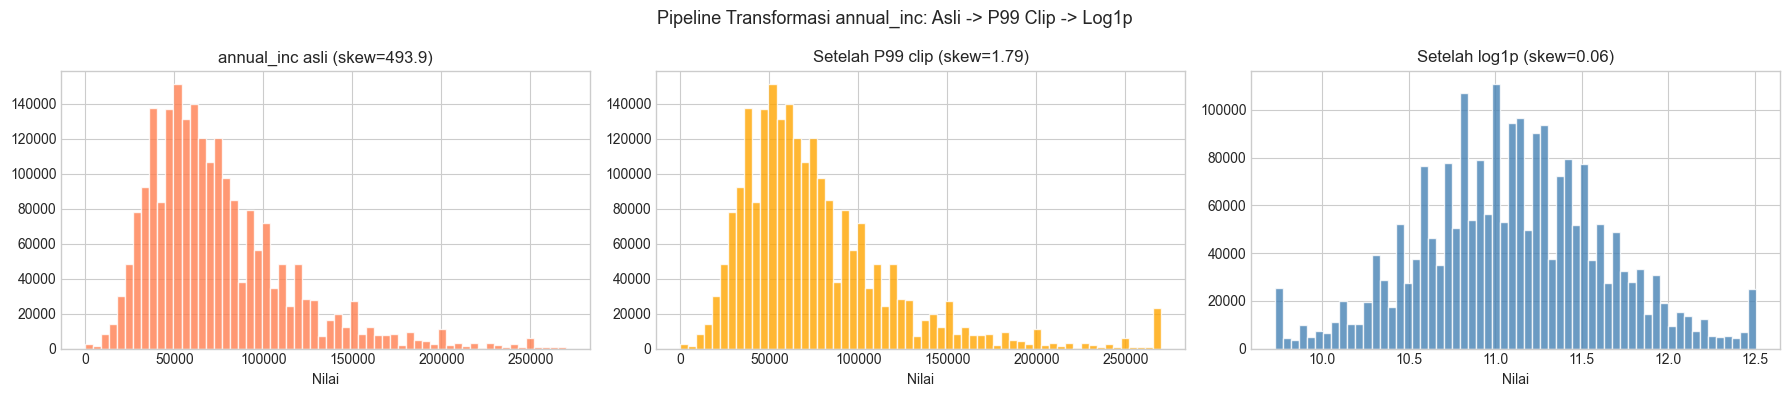

Transformasi annual_inc selesai


In [30]:
# Tahap 1: Percentile clipping P1-P99 untuk annual_inc
if 'annual_inc' in df_acc_clean.columns:
    p1_val  = df_acc_clean['annual_inc'].quantile(0.01)
    p99_val = df_acc_clean['annual_inc'].quantile(0.99)
    df_acc_clean['annual_inc'] = df_acc_clean['annual_inc'].clip(lower=p1_val, upper=p99_val)
    print(f'annual_inc clipped ke [{p1_val:,.0f}, {p99_val:,.0f}]')
    print(f'Skewness setelah P99 clip : {df_acc_clean["annual_inc"].skew():.4f}')

# Simpan skew setelah clipping (SEBELUM log)
skew_clipped = df_acc_clean['annual_inc'].skew()

# Tahap 2: Log transform
log_transform_cols = [c for c in ['annual_inc'] if c in df_acc_clean.columns]

for col in log_transform_cols:
    df_acc_clean[col] = np.log1p(df_acc_clean[col])

print()
print('Skewness sesudah log transform:')
for col in log_transform_cols:
    print(f'  {col}: {df_acc_clean[col].skew():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: distribusi asli (clip P99 untuk tampilan)
raw_data = df_acc['annual_inc'].replace([np.inf, -np.inf], np.nan).dropna()
p99_raw = raw_data.quantile(0.99)
raw_data[raw_data <= p99_raw].hist(bins=60, ax=axes[0], color='coral', edgecolor='white', alpha=0.8)
axes[0].set_title(f'annual_inc asli (skew={raw_data.skew():.1f})')
axes[0].set_xlabel('Nilai')

# Panel 2: setelah P99 clip (sebelum log)
clipped_ref = raw_data.clip(upper=p99_raw)
clipped_ref.hist(bins=60, ax=axes[1], color='orange', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Setelah P99 clip (skew={skew_clipped:.2f})')
axes[1].set_xlabel('Nilai')

# Panel 3: setelah log transform
df_acc_clean['annual_inc'].hist(bins=60, ax=axes[2], color='steelblue', edgecolor='white', alpha=0.8)
axes[2].set_title(f'Setelah log1p (skew={df_acc_clean["annual_inc"].skew():.2f})')
axes[2].set_xlabel('Nilai')

plt.suptitle('Pipeline Transformasi annual_inc: Asli -> P99 Clip -> Log1p', fontsize=13)
plt.tight_layout()
plt.savefig('log_transform_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Transformasi annual_inc selesai')

Insight Log Transform:

annual_inc memiliki outlier ekstrem yang menyebabkan skewness mencapai 493 pada data
setelah cleaning. Tanpa penanganan outlier, log1p akan overcorrect dan menghasilkan
distribusi left-skewed karena log tidak bisa mengompresi nilai yang ratusan kali lebih
besar dari median secara proporsional.

Dengan pipeline P1-P99 clip lalu log1p, skewness turun dari 493 ke 1.79 setelah clip,
lalu ke 0.06 setelah log1p. Skewness 0.06 sangat mendekati distribusi simetris
dan merupakan hasil yang baik untuk fitur ini.

dti tidak ditransformasi karena skewnessnya sudah ~0.35 setelah IQR capping,
yang tergolong hampir simetris. StandardScaler sudah cukup untuk menstandarisasi dti.

## 2.5 — Cleaning df_rej: Pipeline Terpisah

In [31]:
df_rej_clean = df_rej.copy()
print(f'Shape awal: {df_rej_clean.shape}')


Shape awal: (27648741, 9)


Langkah 1 df_rej: Hapus duplikat.
Baris identik adalah redundansi data dan tidak menambah informasi.

In [32]:
n_dupes = df_rej_clean.duplicated().sum()
print(f'Jumlah duplikat: {n_dupes:,}')
df_rej_clean.drop_duplicates(inplace=True)
print(f'Shape setelah drop duplikat: {df_rej_clean.shape}')

Jumlah duplikat: 157,954
Shape setelah drop duplikat: (27490787, 9)


Langkah 2 df_rej: Fix kolom Debt-To-Income Ratio.
Nilai berformat string seperti '10%' dan '38.64%' harus dikonversi ke float
agar bisa digunakan untuk analisis numerik.

In [33]:
if 'Debt-To-Income Ratio' in df_rej_clean.columns:
    print('Sebelum:', df_rej_clean['Debt-To-Income Ratio'].dtype)
    df_rej_clean['Debt-To-Income Ratio'] = (
        df_rej_clean['Debt-To-Income Ratio']
        .str.replace('%', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
    print('Sesudah:', df_rej_clean['Debt-To-Income Ratio'].dtype)
    print(df_rej_clean['Debt-To-Income Ratio'].describe())

Sebelum: object
Sesudah: float64
count   27490787.00
mean         143.41
std        10566.67
min           -1.00
25%            8.10
50%           19.98
75%           36.53
max     50000031.49
Name: Debt-To-Income Ratio, dtype: float64


Langkah 3 df_rej: Handle missing values.
Risk_Score memiliki missing 66.9% sehingga di-drop karena tidak bisa diimputasi secara andal.
Kolom lain diimputasi dengan median untuk numerik dan modus untuk kategorik.

In [34]:
print('Missing sebelum:')
print(df_rej_clean.isnull().sum())

missing_rej_pct = df_rej_clean.isnull().mean() * 100
cols_drop_rej = missing_rej_pct[missing_rej_pct > 50].index.tolist()
print(f'\nDrop kolom (>50% missing): {cols_drop_rej}')
df_rej_clean.drop(columns=cols_drop_rej, inplace=True)

for col in df_rej_clean.select_dtypes(include='object').columns:
    if df_rej_clean[col].isnull().any():
        df_rej_clean[col].fillna(df_rej_clean[col].mode()[0], inplace=True)

for col in df_rej_clean.select_dtypes(include='number').columns:
    if df_rej_clean[col].isnull().any():
        df_rej_clean[col].fillna(df_rej_clean[col].median(), inplace=True)

print(f'Missing setelah cleaning: {df_rej_clean.isnull().sum().sum()}')
print(f'Shape final df_rej_clean: {df_rej_clean.shape}')

Missing sebelum:
Amount Requested               0
Application Date               0
Loan Title                  1285
Risk_Score              18359858
Debt-To-Income Ratio           0
Zip Code                     292
State                         22
Employment Length         949702
Policy Code                  918
dtype: int64

Drop kolom (>50% missing): ['Risk_Score']
Missing setelah cleaning: 0
Shape final df_rej_clean: (27490787, 8)


Langkah 4 df_rej: Fix kolom Employment Length.
Nilai berupa string seperti '10+ years' dikonversi ke angka ordinal untuk konsistensi
dengan emp_length di df_acc.

In [35]:
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}

if 'Employment Length' in df_rej_clean.columns:
    df_rej_clean['Employment Length'] = df_rej_clean['Employment Length'].map(emp_map)
    df_rej_clean['Employment Length'].fillna(df_rej_clean['Employment Length'].median(), inplace=True)
    print('Employment Length berhasil dikonversi ke angka')

Employment Length berhasil dikonversi ke angka


---
# Fase 3 — Data Transformation

Tujuan: Ubah bentuk data agar algoritma machine learning bisa memproses dengan optimal.

## 3.1 — Encoding Target Variable (loan_status)

Langkah 1 Fase 3: Encoding target variable loan_status ke binary.
Fokus pada klasifikasi binary Fully Paid vs Default & Charged Off. Status lain seperti Current dan Late
belum memiliki outcome final sehingga dibuang agar tidak menambah noise pada model.

In [36]:
print('Nilai unik loan_status:', df_acc_clean['loan_status'].unique())
print('\nDistribusi:')
print(df_acc_clean['loan_status'].value_counts())

status_map = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1,
}

df_acc_clean['loan_status_binary'] = df_acc_clean['loan_status'].map(status_map)

before = len(df_acc_clean)
df_acc_clean.dropna(subset=['loan_status_binary'], inplace=True)
after = len(df_acc_clean)

print(f'\nBaris dihapus (loan masih berjalan): {before - after:,}')
print('\nDistribusi target binary:')
print(df_acc_clean['loan_status_binary'].value_counts())
print('0 = Fully Paid, 1 = Default/Charged Off')

Nilai unik loan_status: ['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']

Distribusi:
loan_status
Fully Paid                                             1076752
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Baris dihapus (loan masih berjalan): 912,569

Distribusi target binary:
loan_status_binary
0.00    1078740
1.00     269360
Name: count, dty

## 3.1b — Class Imbalance Analysis

In [37]:
y_temp = df_acc_clean['loan_status_binary'].dropna().astype(int)

print('Class Imbalance Analysis:')
print(f'  Fully Paid (0): {(y_temp==0).sum():,} ({(y_temp==0).mean()*100:.1f}%)')
print(f'  Default    (1): {(y_temp==1).sum():,} ({(y_temp==1).mean()*100:.1f}%)')
print(f'  Rasio      : {(y_temp==0).sum()/(y_temp==1).sum():.1f} : 1')

Class Imbalance Analysis:
  Fully Paid (0): 1,078,740 (80.0%)
  Default    (1): 269,360 (20.0%)
  Rasio      : 4.0 : 1


Langkah 2 Fase 3: Visualisasi class imbalance dan dokumentasi implikasinya.

Insight Class Imbalance:

Dataset ini memiliki distribusi kelas 80% Fully Paid dan 20% Default dengan rasio 4:1.
Ini merupakan imbalance yang moderat dan berdampak langsung pada konfigurasi algoritma
yang akan digunakan selanjutnya.

Untuk Apriori, min_support harus di-set rendah minimal 0.05 agar pola kelas minoritas
Default tetap terdeteksi. Untuk K-Means dan DBSCAN, klaster yang terbentuk kemungkinan
didominasi pola Fully Paid sehingga diperlukan post-hoc analysis per klaster untuk
melihat komposisi Default.

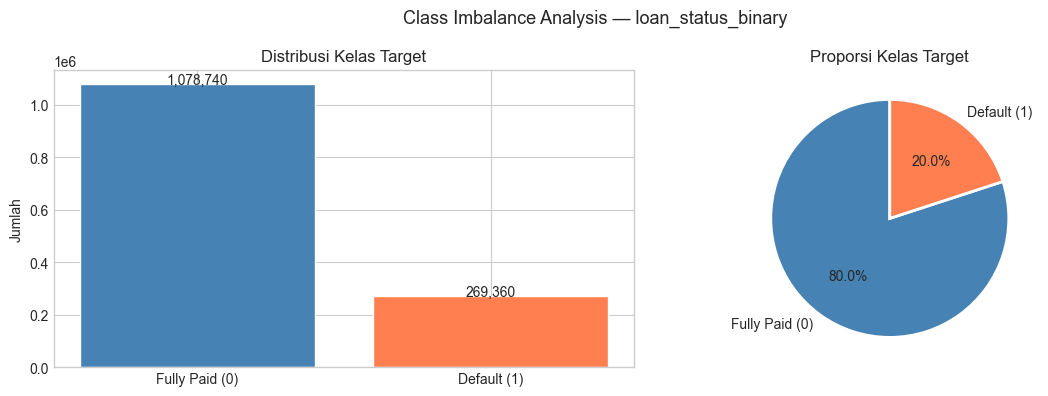

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels_ci = ['Fully Paid (0)', 'Default (1)']
values_ci = [(y_temp==0).sum(), (y_temp==1).sum()]
colors_ci = ['steelblue', 'coral']

axes[0].bar(labels_ci, values_ci, color=colors_ci, edgecolor='white')
axes[0].set_title('Distribusi Kelas Target', fontsize=12)
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(values_ci):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center')

axes[1].pie(values_ci, labels=labels_ci, colors=colors_ci,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kelas Target', fontsize=12)

plt.suptitle('Class Imbalance Analysis — loan_status_binary', fontsize=13)
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()

## 3.2 — Encoding Fitur Kategorik

Langkah 3 Fase 3: Ordinal Encoding untuk kolom dengan urutan natural.
Grade (A sampai G) memiliki hierarki yang bermakna secara bisnis sehingga label encoding
lebih tepat daripada one-hot encoding.

In [39]:
if 'grade' in df_acc_clean.columns:
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df_acc_clean['grade'] = df_acc_clean['grade'].map(grade_map)
    print('grade encoded:', sorted(df_acc_clean['grade'].unique()))

if 'sub_grade' in df_acc_clean.columns:
    le = LabelEncoder()
    df_acc_clean['sub_grade'] = le.fit_transform(df_acc_clean['sub_grade'].astype(str))
    print(f'sub_grade encoded: {df_acc_clean["sub_grade"].nunique()} nilai unik')

grade encoded: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
sub_grade encoded: 35 nilai unik


Langkah 4 Fase 3: One-Hot Encoding untuk kolom nominal tanpa urutan natural.
drop_first=True untuk menghindari dummy variable trap yang menyebabkan multikolinearitas.

In [40]:
ohe_cols = ['home_ownership', 'verification_status', 'purpose',
            'disbursement_method', 'initial_list_status']
ohe_cols = [c for c in ohe_cols if c in df_acc_clean.columns]

shape_before = df_acc_clean.shape
df_acc_clean = pd.get_dummies(df_acc_clean, columns=ohe_cols, drop_first=True, dtype=int)

print(f'Kolom di-OHE: {ohe_cols}')
print(f'Shape sebelum OHE: {shape_before}')
print(f'Shape sesudah OHE : {df_acc_clean.shape}')
print(f'Kolom baru: {df_acc_clean.shape[1] - shape_before[1]}')

Kolom di-OHE: ['home_ownership', 'verification_status', 'purpose', 'disbursement_method', 'initial_list_status']
Shape sebelum OHE: (1348100, 94)
Shape sesudah OHE : (1348100, 111)
Kolom baru: 17


## 3.3 — Normalisasi (Scaling)

Langkah 5 Fase 3: Normalisasi dengan StandardScaler.
annual_inc sudah lebih mendekati normal setelah log transform.
dti sudah mendekati normal setelah IQR capping maka tidak perlu log transform.
StandardScaler dipilih karena menghasilkan mean=0 dan std=1 yang optimal untuk algoritma
berbasis jarak seperti K-Means dan DBSCAN, serta lebih robust terhadap sisa outlier
dibanding MinMaxScaler. Kolom biner hasil OHE dan target dikecualikan karena sudah
dalam range yang sesuai.

In [41]:
target_col = 'loan_status_binary'
cols_to_exclude = [target_col, 'loan_status']

# Simpan hasil log (sebelum scaling) untuk visualisasi
log_temp = df_acc_clean['annual_inc'].copy()

numeric_for_scale = [
    c for c in df_acc_clean.select_dtypes(include='number').columns
    if c not in cols_to_exclude and df_acc_clean[c].nunique() > 2
]

print(f'Jumlah kolom yang akan di-scale: {len(numeric_for_scale)}')

scaler = StandardScaler()
df_acc_clean[numeric_for_scale] = scaler.fit_transform(df_acc_clean[numeric_for_scale])
print('StandardScaler diterapkan')
print(f'Shape: {df_acc_clean.shape}')

Jumlah kolom yang akan di-scale: 68
StandardScaler diterapkan
Shape: (1348100, 111)


Visualisasi perbandingan annual_inc.
Panel kiri menunjukkan distribusi setelah P99 clip, dan log1p (sebelum scaling).
Panel kanan menunjukkan distribusi setelah StandardScaler.

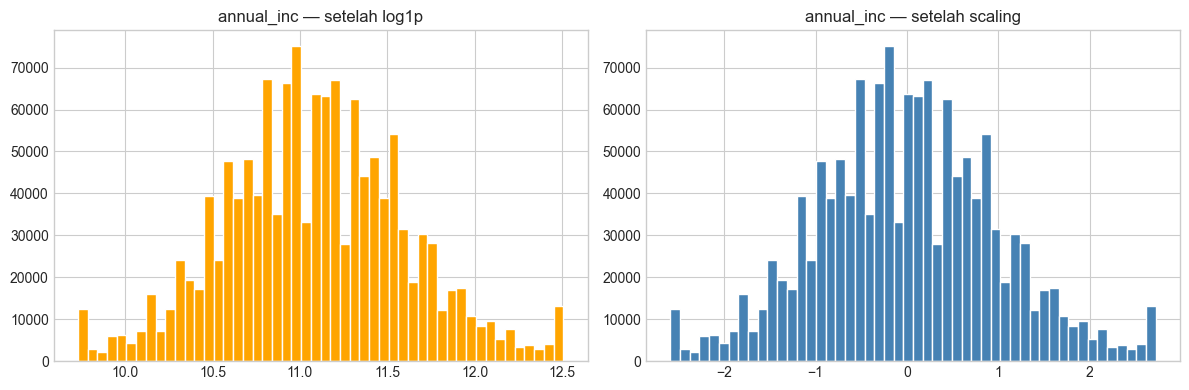

In [42]:
sample_col = 'annual_inc' if 'annual_inc' in numeric_for_scale else numeric_for_scale[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ======================
# KIRI: setelah log1p
# ======================
axes[0].hist(log_temp, bins=50, color='orange', edgecolor='white')
axes[0].set_title(f'{sample_col} — setelah log1p')

# ======================
# KANAN: setelah scaling
# ======================
scaled_data = df_acc_clean[sample_col]
axes[1].hist(scaled_data, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title(f'{sample_col} — setelah scaling')

plt.tight_layout()
plt.savefig('normalisasi_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Normalisasi:

Setelah StandardScaler, semua fitur numerik kontinu berada pada skala mean=0 dan std=1.
annual_inc yang sudah di-log transform akan semakin terstandardisasi dengan baik.
dti yang sudah simetris setelah IQR capping juga distandarisasi tanpa perlu transformasi tambahan.

StandardScaler optimal untuk algoritma berbasis jarak seperti K-Means dan DBSCAN karena
keduanya sangat sensitif terhadap perbedaan skala — fitur dengan rentang besar akan
mendominasi perhitungan jarak jika tidak di-scale. Kolom biner hasil OHE tidak perlu
di-scale karena sudah berada dalam range 0-1 secara alami.

## 3.4 — Binning (Diskretisasi Variabel Kontinu)

Binning dilakukan menggunakan nilai asli dari df_acc (data RAW) karena
interpretasi kategori hanya bermakna pada skala aslinya.

Empat fitur yang di-bin:
- loan_amnt: dibagi berdasarkan ukuran pinjaman (Micro, Small, Medium, Large, Very Large)
- annual_inc: dibagi berdasarkan kelompok pendapatan (Low hingga Very High)
- int_rate: dibagi berdasarkan rentang suku bunga sebagai proksi risiko kredit
- dti: dibagi berdasarkan kategori risiko keuangan mengikuti standar industri lending

Binning loan_amnt

In [43]:
df_binned = df_acc.copy()

if 'loan_amnt' in df_binned.columns:
    df_binned['loan_amnt_bin'] = pd.cut(
        df_binned['loan_amnt'],
        bins=[0, 5000, 10000, 20000, 35000, float('inf')],
        labels=['Micro (<5K)', 'Small (5-10K)', 'Medium (10-20K)', 'Large (20-35K)', 'Very Large (>35K)']
    )
    print('loan_amnt_bin:')
    print(df_binned['loan_amnt_bin'].value_counts())

df_acc_clean['loan_amnt_bin'] = pd.cut(
    df_acc['loan_amnt'],
    bins=[0, 5000, 10000, 20000, 35000, float('inf')],
    labels=[0, 1, 2, 3, 4]
).astype(float)

loan_amnt_bin:
loan_amnt_bin
Medium (10-20K)      826275
Small (5-10K)        597926
Large (20-35K)       492324
Micro (<5K)          299371
Very Large (>35K)     44772
Name: count, dtype: int64


Binning annual_inc

In [44]:
if 'annual_inc' in df_binned.columns:
    df_binned['income_bin'] = pd.cut(
        df_binned['annual_inc'],
        bins=[0, 30000, 60000, 100000, 200000, float('inf')],
        labels=['Low (<30K)', 'Lower-Mid (30-60K)', 'Mid (60-100K)', 'High (100-200K)', 'Very High (>200K)']
    )
    print('income_bin:')
    print(df_binned['income_bin'].value_counts())

df_acc_clean['annual_inc_bin'] = pd.cut(
    df_acc['annual_inc'],
    bins=[0, 30000, 60000, 100000, 200000, float('inf')],
    labels=[0, 1, 2, 3, 4]
).astype(float)

income_bin:
income_bin
Lower-Mid (30-60K)    846684
Mid (60-100K)         796021
High (100-200K)       393761
Low (<30K)            169139
Very High (>200K)      53392
Name: count, dtype: int64


Binning dti mengikuti standar industri keuangan:
Very Low (< 10): kewajiban utang sangat kecil relatif terhadap pendapatan.
Low (10-20): terkelola baik, masih dalam batas aman.
Medium (20-30): mulai perlu perhatian.
High (30-40): berisiko menurut standar lending.
Very High (> 40): risiko tinggi gagal bayar.

Proporsi kategori High dan Very High relevan sebagai pertimbangan minimum support
threshold saat menjalankan Apriori.

In [45]:
if 'dti' in df_binned.columns:
    df_binned['dti_bin'] = pd.cut(
        df_binned['dti'],
        bins=[0, 10, 20, 30, 40, float('inf')],
        labels=['Very Low (<10)', 'Low (10-20)', 'Medium (20-30)', 'High (30-40)', 'Very High (>40)']
    )
    print('dti_bin:')
    print(df_binned['dti_bin'].value_counts())

df_acc_clean['dti_bin'] = pd.cut(
    df_acc['dti'],
    bins=[0, 10, 20, 30, 40, float('inf')],
    labels=[0, 1, 2, 3, 4]
).astype(float)

print('\nDistribusi dti_bin:')
print(df_acc_clean['dti_bin'].value_counts().sort_index())

dti_bin:
dti_bin
Low (10-20)        922666
Medium (20-30)     682257
Very Low (<10)     406902
High (30-40)       218220
Very High (>40)     27178
Name: count, dtype: int64

Distribusi dti_bin:
dti_bin
0.00    246152
1.00    563348
2.00    409035
3.00    121541
4.00      6766
Name: count, dtype: int64


Binning int_rate (suku bunga)

In [46]:
if 'int_rate' in df_binned.columns:
    df_binned['int_rate_bin'] = pd.cut(
        df_binned['int_rate'],
        bins=[0, 8, 12, 16, 20, float('inf')],
        labels=['Very Low (<8%)', 'Low (8-12%)', 'Medium (12-16%)', 'High (16-20%)', 'Very High (>20%)']
    )
    print('int_rate_bin:')
    print(df_binned['int_rate_bin'].value_counts())

df_acc_clean['int_rate_bin'] = pd.cut(
    df_acc['int_rate'],
    bins=[0, 8, 12, 16, 20, float('inf')],
    labels=[0, 1, 2, 3, 4]
).astype(float)

int_rate_bin:
int_rate_bin
Low (8-12%)         664704
Medium (12-16%)     661910
Very Low (<8%)      382213
High (16-20%)       374032
Very High (>20%)    177809
Name: count, dtype: int64


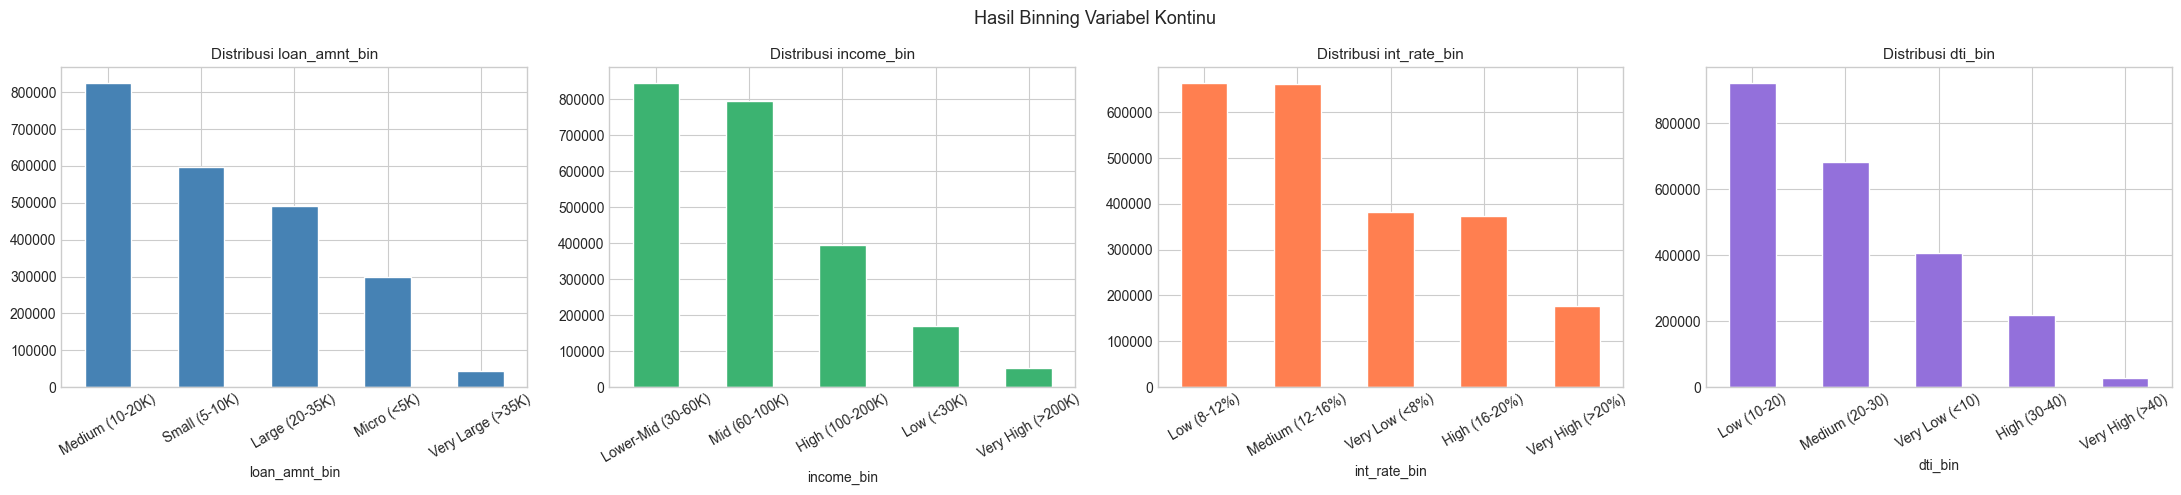

In [47]:
bin_cols = ['loan_amnt_bin', 'income_bin', 'int_rate_bin', 'dti_bin']
bin_cols = [c for c in bin_cols if c in df_binned.columns]

fig, axes = plt.subplots(1, len(bin_cols), figsize=(22, 5))
colors = ['steelblue', 'mediumseagreen', 'coral', 'mediumpurple']

for i, col in enumerate(bin_cols):
    df_binned[col].value_counts().plot(kind='bar', ax=axes[i], color=colors[i], edgecolor='white')
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Hasil Binning Variabel Kontinu', fontsize=13)
plt.tight_layout()
plt.savefig('binning_result.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Hasil Binning:

loan_amnt_bin menunjukkan mayoritas pinjaman berada pada kategori Small hingga Medium (5K–20K), mencerminkan kebutuhan pembiayaan skala menengah.

income_bin menunjukkan distribusi condong ke kategori Lower-Mid (30-60K) dan Mid (60-100K).
Kategori Very High di atas 200K adalah minoritas namun penting untuk profil risiko rendah.

int_rate_bin terkonsentrasi pada kategori Low–Medium (8–16%), yang mengindikasikan sebagian besar pinjaman berada pada tingkat bunga moderat.

dti_bin menunjukkan bahwa sebagian besar peminjam berada pada rasio utang rendah hingga sedang, namun kategori High dan Very High (>30) tetap perlu diperhatikan karena berpotensi memiliki risiko gagal bayar lebih tinggi meskipun proporsinya kecil.

Keempat binning ini siap digunakan langsung untuk Apriori tanpa preprocessing tambahan.

---
# Fase 4 — Feature Selection

Tujuan: Pilih fitur yang paling relevan terhadap target dan buang fitur redundan atau tidak relevan.

Dua metode yang digunakan:
1. Correlation Analysis untuk mengukur hubungan linear antar fitur numerik dan target.
2. Mutual Information berbasis Entropy untuk menangkap hubungan linear maupun non-linear.

## 4.1 — Persiapan Data untuk Feature Selection

In [48]:
cols_to_exclude_fs = ['loan_status', 'loan_status_binary']
feature_cols = [
    c for c in df_acc_clean.columns
    if c not in cols_to_exclude_fs and df_acc_clean[c].dtype != 'object'
]

X = df_acc_clean[feature_cols].fillna(0) #safety aja
y = df_acc_clean['loan_status_binary'].astype(int)

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Distribusi target: {y.value_counts().to_dict()}')

Shape X: (1348100, 108)
Shape y: (1348100,)
Distribusi target: {0: 1078740, 1: 269360}


## 4.2 — Correlation Analysis (Pearson Correlation)

Metode 1: Pearson Correlation.  
Mengukur hubungan LINEAR antara fitur dan target.  
|corr| > 0.1 : lemah tapi relevan untuk dataset besar.  
|corr| > 0.3 : moderat.  
|corr| > 0.5 : kuat.  
Juga digunakan untuk deteksi multikolinearitas antar fitur (corr > 0.9).  

In [49]:
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)

corr_df = pd.DataFrame({
    'Feature': corr_with_target.index,
    'Correlation': corr_with_target.values
})
print('Top 20 fitur dengan korelasi tertinggi terhadap loan_status_binary:')
print(corr_df.head(20).to_string(index=False))

Top 20 fitur dengan korelasi tertinggi terhadap loan_status_binary:
                 Feature  Correlation
    last_fico_range_high         0.67
     last_fico_range_low         0.66
               sub_grade         0.27
                   grade         0.26
                int_rate         0.26
            int_rate_bin         0.25
 last_credit_pull_d_year         0.18
                    term         0.18
          fico_range_low         0.13
         fico_range_high         0.13
                     dti         0.11
last_credit_pull_d_month         0.11
                 dti_bin         0.10
    acc_open_past_24mths         0.10
          bc_open_to_buy         0.09
      num_tl_op_past_12m         0.08
             avg_cur_bal         0.08
         tot_hi_cred_lim         0.08
          total_bc_limit         0.07
                mort_acc         0.07


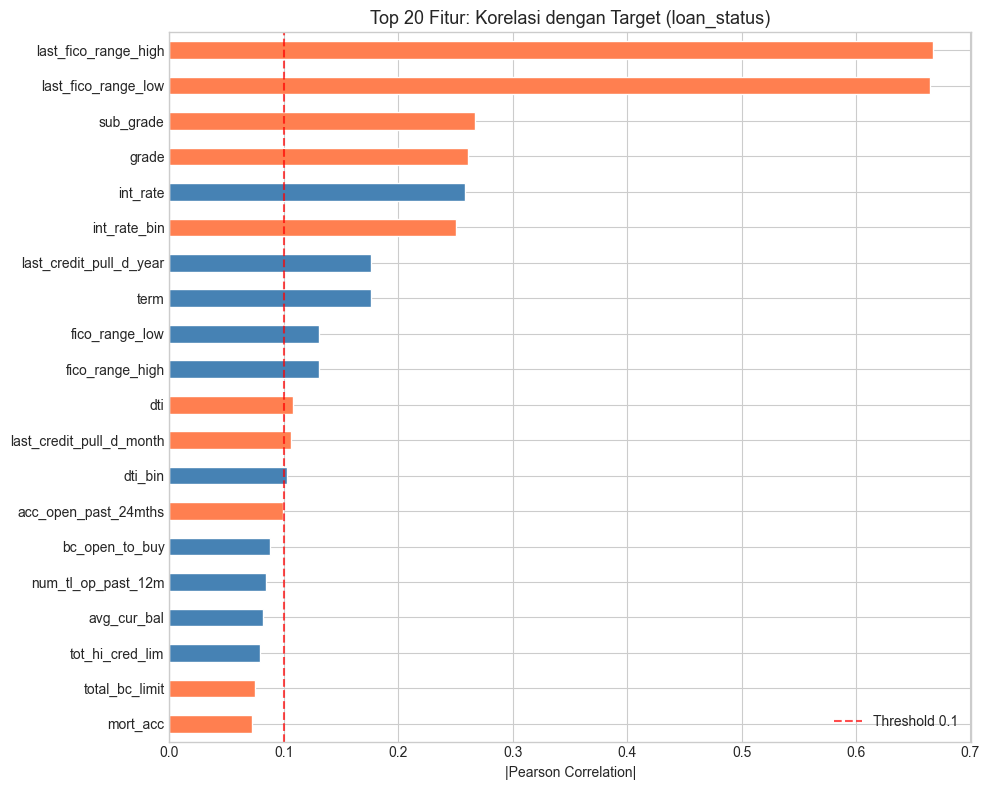

In [50]:
fig, ax = plt.subplots(figsize=(10, 8))
top20_corr = corr_with_target.head(20)
colors = ['steelblue' if v > 0 else 'coral' for v in X[top20_corr.index].corrwith(y).head(20)]
top20_corr.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Fitur: Korelasi dengan Target (loan_status)', fontsize=13)
ax.set_xlabel('|Pearson Correlation|')
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='Threshold 0.1')
ax.legend()
plt.tight_layout()
plt.savefig('correlation_target.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Korelasi Fitur vs Target:

Dari output, last_fico_range_high dan last_fico_range_low memiliki korelasi tertinggi
(sekitar 0.66-0.67) dan termasuk kategori kuat. Fitur lainnya seperti sub_grade, grade,
dan int_rate berada di kisaran 0.26-0.27 yang termasuk moderat.

Korelasi negatif berarti semakin tinggi nilai fitur maka semakin kecil probabilitas
default. fico_range yang tinggi menunjukkan peminjam lebih kredibel sehingga risiko
default lebih kecil.

Korelasi positif berarti semakin tinggi nilai fitur maka semakin besar risiko default.
int_rate yang tinggi berarti biaya cicilan lebih berat sehingga risiko gagal bayar naik.

Pearson Correlation hanya mendeteksi hubungan linear. Fitur dengan korelasi rendah belum
tentu tidak informatif karena bisa saja memiliki hubungan non-linear yang terlihat
di Mutual Information.

Deteksi Multikolinearitas Antar Fitur.  
Dua fitur dengan korelasi di atas 0.9 mengandung informasi yang hampir sama sehingga salah satu bisa dibuang tanpa kehilangan informasi prediktif.

In [51]:
top30_features = corr_with_target.head(30).index.tolist()
corr_matrix = X[top30_features].corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 4)
            })

if high_corr_pairs:
    print(f'Pasangan fitur dengan korelasi > 0.9: {len(high_corr_pairs)}')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('Tidak ada pasangan fitur dengan korelasi > 0.9')

Pasangan fitur dengan korelasi > 0.9: 12
           Feature 1           Feature 2  Correlation
last_fico_range_high last_fico_range_low         0.99
           sub_grade               grade         0.98
           sub_grade            int_rate         0.98
           sub_grade        int_rate_bin         0.94
               grade            int_rate         0.95
               grade        int_rate_bin         0.94
            int_rate        int_rate_bin         0.96
      fico_range_low     fico_range_high         1.00
                 dti             dti_bin         0.95
     tot_hi_cred_lim         tot_cur_bal         0.98
     num_actv_rev_tl num_rev_tl_bal_gt_0         0.98
       loan_amnt_bin         funded_amnt         0.91


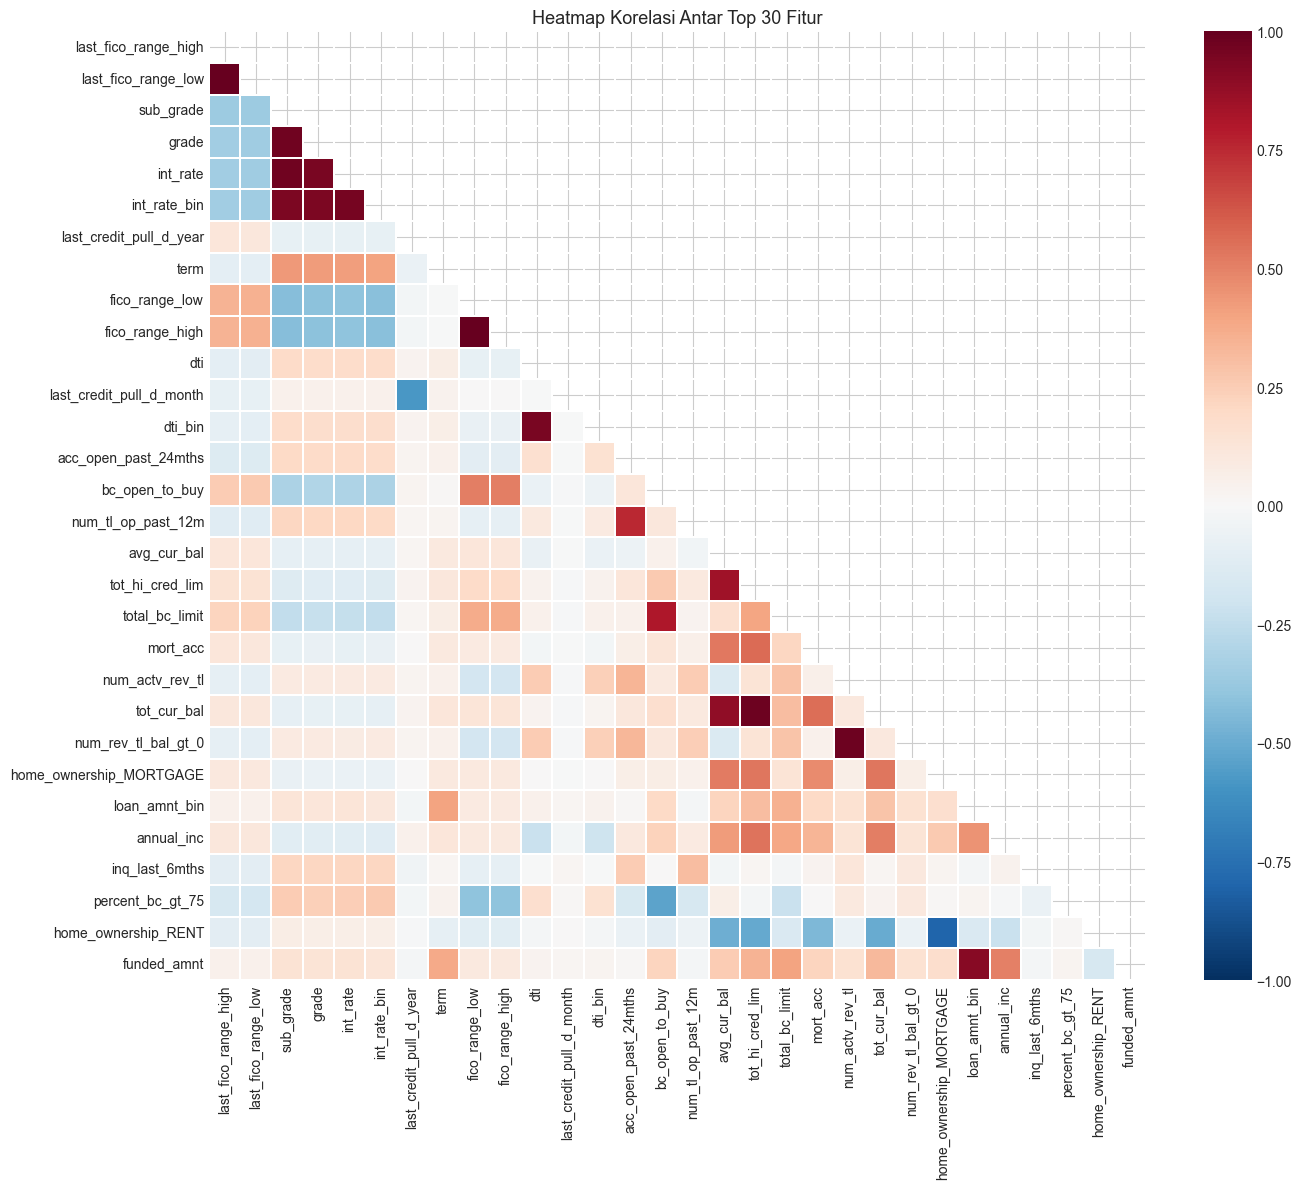

In [52]:
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3
)
ax.set_title('Heatmap Korelasi Antar Top 30 Fitur', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Heatmap Multikolinearitas:

Area berwarna merah gelap dengan korelasi di atas 0.9 antar fitur menandakan multikolinearitas.
Salah satu dari pasangan tersebut bisa dibuang tanpa kehilangan informasi prediktif yang signifikan.

Pasangan seperti grade dan int_rate umumnya berkorelasi tinggi di dataset Lending Club
karena grade menentukan interest rate secara langsung sebagai bagian dari credit policy platform.

Penanganan multikolinearitas berbeda tergantung algoritma yang digunakan:

Untuk Apriori, multikolinearitas tidak menjadi masalah karena algoritma ini bekerja
berbasis frekuensi co-occurrence itemset, bukan perhitungan jarak antar titik data.

Untuk K-Means dan DBSCAN, multikolinearitas PERLU ditangani karena kedua algoritma
berbasis Euclidean distance. Fitur yang berkorelasi tinggi (di atas 0.9) secara efektif
menggandakan bobot dimensi yang sama dalam perhitungan jarak, sehingga mendistorsi
bentuk dan komposisi klaster yang terbentuk.

PCA tidak dipilih sebagai solusi meskipun lebih canggih, karena fase Apriori selanjutnya
membutuhkan nama fitur yang bermakna secara domain untuk interpretasi rules.
Solusi yang digunakan adalah drop satu fitur dari tiap pasangan berkorelasi tinggi,
dengan mempertahankan fitur yang memiliki Combined Score lebih tinggi. Implementasi
ada di Fase 4.5.

## 4.3 — Entropy / Mutual Information

Metode 2: Mutual Information berbasis Entropy.  
MI(X;Y) = H(Y) - H(Y|X) di mana H = entropy (ketidakpastian informasi).

Keunggulan vs Korelasi:
- Menangkap hubungan non-linear.
- Bisa untuk tipe data campuran (numerik + kategorik).
- MI = 0 berarti fitur tidak ada hubungan dengan target.
- MI tinggi berarti fitur sangat informatif.

Menggunakan sampel untuk efisiensi komputasi pada dataset besar.

In [53]:
sample_size = min(100_000, len(X))
X_sample = X.sample(n=sample_size, random_state=42)
y_sample = y.loc[X_sample.index]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print('\nTop 20 fitur berdasarkan Mutual Information:')
print(mi_df.head(20).to_string(index=False))


Top 20 fitur berdasarkan Mutual Information:
                   Feature  MI_Score
       last_fico_range_low      0.26
      last_fico_range_high      0.26
                  int_rate      0.04
                 sub_grade      0.04
                     grade      0.04
              int_rate_bin      0.03
  last_credit_pull_d_month      0.03
               installment      0.02
                      term      0.02
   last_credit_pull_d_year      0.02
               policy_code      0.02
               open_rv_12m      0.02
               open_act_il      0.02
   home_ownership_MORTGAGE      0.02
     initial_list_status_w      0.01
purpose_debt_consolidation      0.01
                   dti_bin      0.01
           fico_range_high      0.01
            fico_range_low      0.01
            annual_inc_bin      0.01


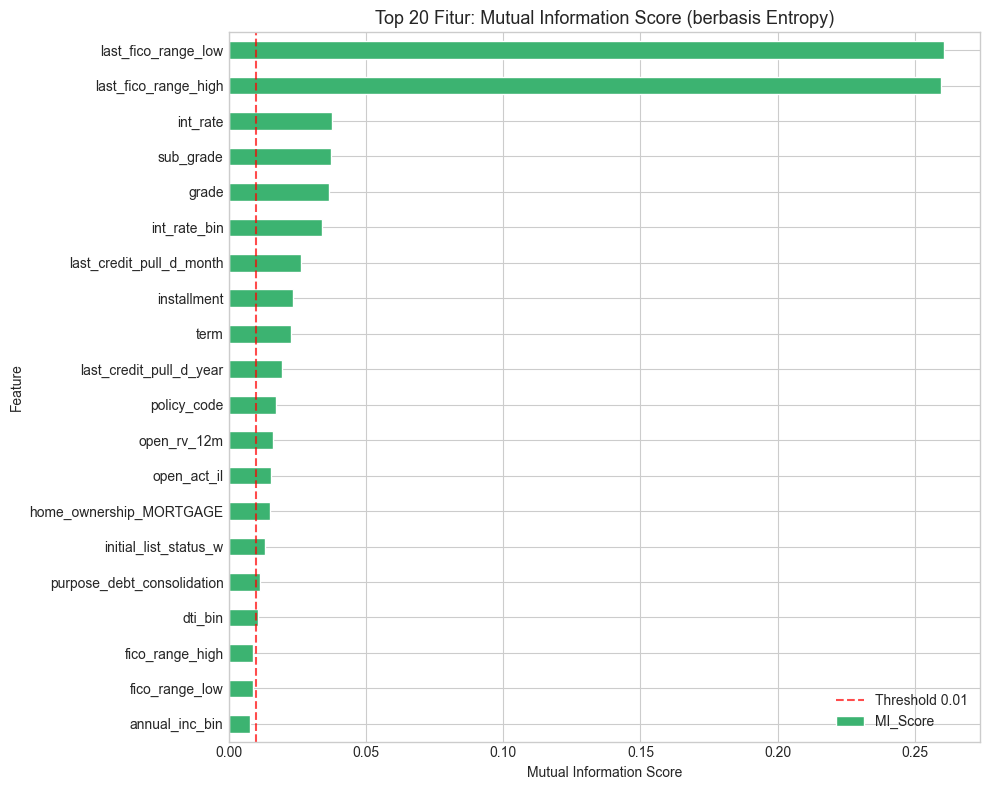

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))
mi_df.head(20).sort_values('MI_Score').plot(
    kind='barh', x='Feature', y='MI_Score',
    ax=ax, color='mediumseagreen', edgecolor='white', legend=False
)
ax.set_title('Top 20 Fitur: Mutual Information Score (berbasis Entropy)', fontsize=13)
ax.set_xlabel('Mutual Information Score')
ax.axvline(x=0.01, color='red', linestyle='--', alpha=0.7, label='Threshold 0.01')
ax.legend()
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Mutual Information Score:

MI Score mengukur seberapa banyak informasi yang dibagikan antara fitur dan target.
Nilai 0 berarti fitur sepenuhnya tidak relevan terhadap target.

Fitur dengan MI Score tinggi menangkap hubungan yang mungkin non-linear sekalipun,
yang tidak terdeteksi oleh Pearson Correlation. Perbedaan urutan fitur antara Mutual Information dan Correlation menunjukkan adanya potensi hubungan non-linear dalam dataset.

Fitur dengan MI Score mendekati 0 bisa dipertimbangkan untuk di-drop pada feature selection final karena hampir tidak memberikan informasi prediktif tentang status pinjaman.

## 4.4 — Gabungkan dan Pilih Fitur Final

Gabungkan skor Korelasi dan Mutual Information.  
Setiap skor dinormalisasi ke [0,1] agar bisa dijumlahkan secara adil.  
Combined_Score adalah rata-rata dari keduanya.  
Pendekatan ensemble ini lebih robust daripada mengandalkan satu metode.  

In [55]:
combined_scores = pd.DataFrame({
    'Feature': corr_with_target.index,
    'Abs_Correlation': corr_with_target.values
}).merge(mi_df, on='Feature', how='inner')

combined_scores['Corr_Norm'] = combined_scores['Abs_Correlation'] / combined_scores['Abs_Correlation'].max()
combined_scores['MI_Norm'] = combined_scores['MI_Score'] / combined_scores['MI_Score'].max()
combined_scores['Combined_Score'] = (combined_scores['Corr_Norm'] + combined_scores['MI_Norm']) / 2

combined_scores = combined_scores.sort_values('Combined_Score', ascending=False)
print('Top 20 fitur berdasarkan Combined Score:')
print(combined_scores.head(20)[['Feature', 'Abs_Correlation', 'MI_Score', 'Combined_Score']].to_string(index=False))

Top 20 fitur berdasarkan Combined Score:
                 Feature  Abs_Correlation  MI_Score  Combined_Score
     last_fico_range_low             0.66      0.26            1.00
    last_fico_range_high             0.67      0.26            1.00
               sub_grade             0.27      0.04            0.27
                   grade             0.26      0.04            0.27
                int_rate             0.26      0.04            0.27
            int_rate_bin             0.25      0.03            0.25
                    term             0.18      0.02            0.18
 last_credit_pull_d_year             0.18      0.02            0.17
last_credit_pull_d_month             0.11      0.03            0.13
         fico_range_high             0.13      0.01            0.12
          fico_range_low             0.13      0.01            0.12
                 dti_bin             0.10      0.01            0.10
                     dti             0.11      0.01            0.09
    acc

In [56]:
top_n = 25
selected_features = combined_scores.head(top_n)['Feature'].tolist()

print(f'{top_n} fitur terpilih untuk dataset final:')
for i, feat in enumerate(selected_features, 1):
    row = combined_scores[combined_scores['Feature'] == feat].iloc[0]
    print(f'  {i:2d}. {feat:<40} | Corr={row["Abs_Correlation"]:.4f} | MI={row["MI_Score"]:.4f}')

25 fitur terpilih untuk dataset final:
   1. last_fico_range_low                      | Corr=0.6648 | MI=0.2607
   2. last_fico_range_high                     | Corr=0.6671 | MI=0.2594
   3. sub_grade                                | Corr=0.2670 | MI=0.0372
   4. grade                                    | Corr=0.2613 | MI=0.0367
   5. int_rate                                 | Corr=0.2586 | MI=0.0377
   6. int_rate_bin                             | Corr=0.2500 | MI=0.0341
   7. term                                     | Corr=0.1757 | MI=0.0228
   8. last_credit_pull_d_year                  | Corr=0.1762 | MI=0.0193
   9. last_credit_pull_d_month                 | Corr=0.1058 | MI=0.0265
  10. fico_range_high                          | Corr=0.1307 | MI=0.0090
  11. fico_range_low                           | Corr=0.1307 | MI=0.0090
  12. dti_bin                                  | Corr=0.1029 | MI=0.0109
  13. dti                                      | Corr=0.1079 | MI=0.0053
  14. acc_op

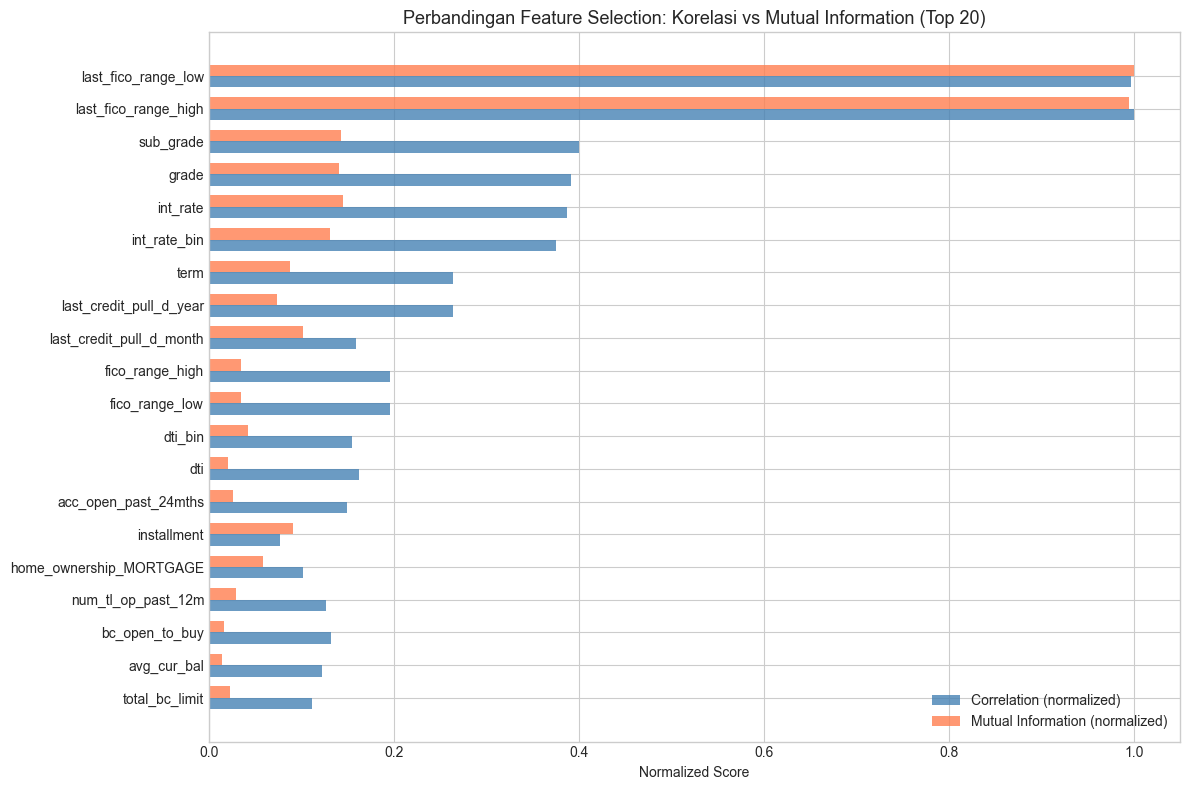

In [57]:
plot_df = combined_scores.head(20).sort_values('Combined_Score')

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(plot_df))
width = 0.35

ax.barh(x - width/2, plot_df['Corr_Norm'], width, label='Correlation (normalized)', color='steelblue', alpha=0.8)
ax.barh(x + width/2, plot_df['MI_Norm'], width, label='Mutual Information (normalized)', color='coral', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(plot_df['Feature'])
ax.set_xlabel('Normalized Score')
ax.set_title('Perbandingan Feature Selection: Korelasi vs Mutual Information (Top 20)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('feature_selection_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Perbandingan Korelasi vs Mutual Information:

Fitur yang konsisten tinggi di kedua metode merupakan kandidat terkuat untuk dimasukkan ke
model karena keduanya mengkonfirmasi relevansi dari sudut pandang linear dan non-linear.

Fitur yang tinggi di MI tetapi rendah di Korelasi mengindikasikan kemungkinan hubungan non-linear
dengan target seperti  outlier, interaksi threshold atau pola U-shape. Fitur ini sering dilewatkan
jika hanya menggunakan korelasi linear saja.

Fitur yang tinggi di Korelasi tetapi rendah di MI umumnya memiliki hubungan linear yang
kuat namun tidak banyak menambah informasi unik di luar fitur lain.

Strategi ensemble yang menggabungkan kedua metode lebih robust dibanding mengandalkan
satu metode saja karena masing-masing memiliki blind spot yang berbeda.

## 4.5 — Drop Fitur Redundan untuk Clustering

Multikolinearitas perlu ditangani sebelum K-Means dan DBSCAN.
Fitur yang berkorelasi tinggi di atas 0.9 menggandakan bobot suatu dimensi dalam
perhitungan Euclidean distance sehingga mendistorsi bentuk klaster.

Dari tiap pasangan berkorelasi tinggi, dipertahankan fitur dengan Combined Score lebih tinggi
karena fitur tersebut lebih informatif terhadap target berdasarkan hasil feature selection.

PCA tidak dipilih karena fase Apriori selanjutnya membutuhkan nama fitur yang bermakna
secara domain untuk interpretasi association rules.

In [ ]:
cols_to_drop_corr = []
seen = set()

print('Analisis pasangan fitur berkorelasi tinggi (>0.9):')
if high_corr_pairs:
    for pair in high_corr_pairs:
        f1, f2 = pair['Feature 1'], pair['Feature 2']
        if f1 in seen or f2 in seen:
            continue
        s1 = combined_scores[combined_scores['Feature'] == f1]['Combined_Score'].values
        s2 = combined_scores[combined_scores['Feature'] == f2]['Combined_Score'].values
        if len(s1) and len(s2):
            drop = f2 if s1[0] >= s2[0] else f1
            keep = f1 if drop == f2 else f2
            cols_to_drop_corr.append(drop)
            seen.update([f1, f2])
            print(f'  Pasangan  : {f1} & {f2}')
            print(f'  Korelasi  : {pair["Correlation"]}')
            print(f'  Pertahankan (score lebih tinggi): {keep}')
            print(f'  Drop      : {drop}')
            print()
else:
    print('  Tidak ada pasangan fitur dengan korelasi > 0.9 di top 30 fitur.')
    print('  Seluruh selected_features dapat langsung digunakan untuk clustering.')

selected_features_final = [f for f in selected_features if f not in cols_to_drop_corr]

print(f'Fitur sebelum deduplikasi       : {len(selected_features)}')
print(f'Fitur di-drop (redundan)        : {len(cols_to_drop_corr)} — {cols_to_drop_corr}')
print(f'Fitur final untuk clustering    : {len(selected_features_final)}')
print()
print('Fitur final:')
for i, f in enumerate(selected_features_final, 1):
    print(f'  {i:2d}. {f}')

Analisis pasangan fitur berkorelasi tinggi (>0.9):
  Pasangan  : last_fico_range_high & last_fico_range_low
  Korelasi  : 0.994
  Pertahankan (score lebih tinggi): last_fico_range_low
  Drop      : last_fico_range_high

  Pasangan  : sub_grade & grade
  Korelasi  : 0.9757
  Pertahankan (score lebih tinggi): sub_grade
  Drop      : grade

  Pasangan  : int_rate & int_rate_bin
  Korelasi  : 0.9556
  Pertahankan (score lebih tinggi): int_rate
  Drop      : int_rate_bin

  Pasangan  : fico_range_low & fico_range_high
  Korelasi  : 1.0
  Pertahankan (score lebih tinggi): fico_range_high
  Drop      : fico_range_low

  Pasangan  : dti & dti_bin
  Korelasi  : 0.9463
  Pertahankan (score lebih tinggi): dti_bin
  Drop      : dti

  Pasangan  : tot_hi_cred_lim & tot_cur_bal
  Korelasi  : 0.984
  Pertahankan (score lebih tinggi): tot_hi_cred_lim
  Drop      : tot_cur_bal

  Pasangan  : num_actv_rev_tl & num_rev_tl_bal_gt_0
  Korelasi  : 0.9821
  Pertahankan (score lebih tinggi): num_rev_tl_bal_gt

Insight Drop Fitur Redundan:

Fitur yang di-drop dipilih berdasarkan Combined Score yang lebih rendah dari pasangannya,
sehingga fitur dengan informasi lebih kaya terhadap target tetap dipertahankan.

Dataset final untuk clustering menggunakan selected_features_final yang sudah bebas dari
redundansi. Dataset ini akan digunakan langsung pada fase K-Means dan DBSCAN.

Untuk fase Apriori setelahnya, fitur-fitur bin seperti int_rate_bin, dti_bin, loan_amnt_bin,
dan annual_inc_bin akan digunakan bersama kolom cluster_label hasil clustering, karena
Apriori membutuhkan fitur kategorik dan tidak terpengaruh oleh multikolinearitas.

---
# Simpan Hasil — Clean Dataset

In [59]:
df_acc_final = df_acc_clean[selected_features_final + ['loan_status_binary']].copy()
df_acc_final.to_csv('clean_accepted_loans.csv', index=False)
print(f'Saved: clean_accepted_loans.csv — {df_acc_final.shape}')

df_rej_clean.to_csv('clean_rejected_loans.csv', index=False)
print(f'Saved: clean_rejected_loans.csv — {df_rej_clean.shape}')

df_rej_clean['loan_outcome'] = 'Rejected'
df_acc_final['loan_outcome'] = df_acc_final['loan_status_binary'].map(
    {0: 'Accepted-Paid', 1: 'Accepted-Default'}
)

Saved: clean_accepted_loans.csv — (1348100, 21)
Saved: clean_rejected_loans.csv — (27490787, 8)


---
# Summary Report — Preprocessing Pipeline

In [60]:
print('=' * 70)
print('PREPROCESSING SUMMARY REPORT — LENDING CLUB LOAN DATASET')
print('=' * 70)

print('\n[1] EXPLORATORY DATA ANALYSIS')
print(f'    df_acc raw             : {df_acc.shape[0]:>10,} rows x {df_acc.shape[1]} cols')
print(f'    df_rej raw             : {df_rej.shape[0]:>10,} rows x {df_rej.shape[1]} cols')
print(f'    df_acc kolom kategorik : {len(df_acc.select_dtypes(include="object").columns)}')
print(f'    df_acc kolom numerik   : {len(df_acc.select_dtypes(include="number").columns)}')

print('\n[2] DATA CLEANING — df_acc')
print(f'    Kolom di-drop (>50% missing)   : {len(cols_to_drop_missing)}')
print(f'    Kolom di-drop (non-informatif) : {len(cols_to_drop_manual)}')
print(f'    Kolom di-drop (leaky)          : {len(leaky_cols)}')
print(f'    Kolom skewed di-capping        : {len(skewed_cols)}')

print('\n[3] DATA TRANSFORMATION')
print(f'    Log transform diterapkan pada  : {log_transform_cols}')
print(f'    Kolom di-scale                 : {len(numeric_for_scale)}')
print(f'    Kolom di-OHE                   : {len(ohe_cols)}')

print('\n[4] FEATURE SELECTION')
print(f'    Total fitur setelah preprocessing : {X.shape[1]}')
print(f'    Fitur di-drop (redundan corr>0.9): {len(cols_to_drop_corr)}')
print(f'    Fitur final untuk clustering      : {len(selected_features_final)}')
print(f'    Fitur terpilih (top {top_n})          : {len(selected_features)}')
print(f'    Metode: Pearson Correlation + Mutual Information')

print('\n[5] CLASS IMBALANCE')
y_final = df_acc_clean['loan_status_binary'].astype(int)
print(f'    Fully Paid (0) : {(y_final==0).sum():,} ({(y_final==0).mean()*100:.1f}%)')
print(f'    Default    (1) : {(y_final==1).sum():,} ({(y_final==1).mean()*100:.1f}%)')
print(f'    Catatan: min_support Apriori disarankan >= 0.05 untuk mendeteksi pola kelas minoritas')

print('\nPreprocessing pipeline selesai.')

PREPROCESSING SUMMARY REPORT — LENDING CLUB LOAN DATASET

[1] EXPLORATORY DATA ANALYSIS
    df_acc raw             :  2,260,701 rows x 151 cols
    df_rej raw             : 27,648,741 rows x 9 cols
    df_acc kolom kategorik : 38
    df_acc kolom numerik   : 113

[2] DATA CLEANING — df_acc
    Kolom di-drop (>50% missing)   : 44
    Kolom di-drop (non-informatif) : 5
    Kolom di-drop (leaky)          : 12
    Kolom skewed di-capping        : 39

[3] DATA TRANSFORMATION
    Log transform diterapkan pada  : ['annual_inc']
    Kolom di-scale                 : 68
    Kolom di-OHE                   : 5

[4] FEATURE SELECTION
    Total fitur setelah preprocessing : 108
    Fitur di-drop (redundan corr>0.9): 8
    Fitur final untuk clustering      : 20
    Fitur terpilih (top 25)          : 25
    Metode: Pearson Correlation + Mutual Information

[5] CLASS IMBALANCE
    Fully Paid (0) : 1,078,740 (80.0%)
    Default    (1) : 269,360 (20.0%)
    Catatan: min_support Apriori disarankan >= 0.05